# Assignment 1A Part A
## Continual Pre-Training for Cisco Data Center Networking

This notebook documents the end-to-end continual pre-training pipeline used to adapt a causal language model to Cisco data-center networking material. It covers source extraction and cleaning, tokenizer-aligned sequence packing, model inspection, CPT training, and evaluation using held-out perplexity and a catastrophic-forgetting check.

## Table of Contents

1. [Implementation Overview](#implementation-overview)
2. [Step 1 Data Collection Extraction and Cleaning](#step-1-data-collection-extraction-and-cleaning)
3. [Step 2 Tokenization and Packed Dataset](#step-2-tokenization-and-packed-dataset)
4. [Step 3 Model Loading and Architecture Inspection](#step-3-model-loading-and-architecture-inspection)
5. [Step 4 CPT Training Loop and Loss Analysis](#step-4-cpt-training-loop-and-loss-analysis)
6. [Step 5 Perplexity and Catastrophic Forgetting Evaluation](#step-5-perplexity-and-catastrophic-forgetting-evaluation)
7. [Generated Artifacts](#generated-artifacts)

<a id="implementation-overview"></a>
## Implementation Overview

| Stage | Implementation | Main evidence |
|---|---|---|
| Data preparation | Recursive PDF/text loading, normalization, quality gates, deduplication and content cleanup | Cleaned text and JSON audit reports |
| Tokenization | Pretrained model tokenizer, document boundaries, fixed-length sequence packing and document-level train/test split | Binary tokens, Parquet sequences and dataset metrics |
| Model inspection | Generic causal-LM loading and architecture/tokenizer validation | Model configuration and parameter summary |
| CPT | Memory-mapped packed dataset, next-token training, gradient accumulation and checkpointing | Training history, loss curve and final model |
| Evaluation | Base-versus-CPT perplexity on the same held-out split and general-prompt retention analysis | Evaluation JSON and comparison tables |

<a id="step-1-data-collection-extraction-and-cleaning"></a>
## Step 1 Data Collection Extraction and Cleaning

### Selected Domain
* **Primary Domain:** Networking Domain
* **Specialization:** Data Center Products and Features

### Corpus Composition
The domain corpus combines three primary sources:
1. Publicly available Cisco data-center product documentation
2. Product configuration guides
3. Standard networking RFC text

### Text extraction from PDF and txt files

Following code does the extraction from PDF and text files that are given as raw input
This is a parallel pipeline with worker processes taking care of each file in parallel.

* **Recursive Processing:** Accepts both PDF and plain-text source files recursively.
* **Extraction Methods:**
  * **PDFs:** Page-by-page text extraction integrated with dedicated table extraction.
  * **Text Files:** Existing `.txt` files are read directly without overhead.
* **Efficiency & Optimization:**
  * **Incremental Extraction:** Avoids repeating processing work for unchanged or previously parsed documents.
  * **Resource Management:** Implements worker limits to reduce memory pressure during execution.



In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
os.environ["CACHE_DIR"] = "/home/jovyan/llmgenai/hf_cache"
print(PROJECT_ROOT, os.environ.get("CACHE_DIR"))

/home/jovyan/llmassign/1a /home/jovyan/llmgenai/hf_cache


In [2]:
import hashlib
import os
import re
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path

import pdfplumber


# --- Worker functions placed at module-level for clean multiprocessing pickling ---

# Why these extraction and corpus checks are used:
# - MD5 is an extraction-cache fingerprint. If the source PDF is unchanged,
#   its existing text can be reused instead of repeating expensive PDF and
#   table extraction. The MD5 header is removed before training, so it never
#   becomes model-learning content.
# - The length check rejects empty, failed, or uninformative extractions.
# - The repetition check rejects documents where duplicated paragraphs exceed
#   30%, preventing page furniture or extraction loops from dominating CPT.
# - The language check keeps the corpus consistently English.
# - Corpus deduplication prevents repeated documents from receiving excessive
#   training weight; each rejected duplicate retains a reference to the copy kept.

def _calculate_md5(file_path: Path) -> str:
    """Calculate the MD5 hash of a file by reading it in binary chunks."""
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(8192):
            hasher.update(chunk)
    return hasher.hexdigest()


def _read_existing_md5(txt_path: Path) -> str | None:
    """Read the first line of an existing text file to extract the stored MD5 hash."""
    if not txt_path.exists():
        return None
    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            first_line = f.readline().strip()
            if first_line.startswith("# MD5:"):
                return first_line.split("# MD5:")[1].strip()
    except Exception:
        return None
    return None


def _is_char_in_bbox(char: dict, bbox: tuple) -> bool:
    """Check if a character's coordinates fall inside a table bounding box."""
    c_x0 = char.get("x0", 0)
    c_top = char.get("top", 0)
    c_x1 = char.get("x1", 0)
    c_bottom = char.get("bottom", 0)

    t_x0, t_top, t_x1, t_bottom = bbox
    return not (c_x1 < t_x0 or c_x0 > t_x1 or c_bottom < t_top or c_top > t_bottom)


def _format_table_as_markdown(table: list) -> str:
    """Convert a 2D list (table) into a Markdown grid string."""
    if not table or not any(table):
        return ""

    clean_table = [
        [str(cell).replace("\n", " ").strip() if cell else "" for cell in row]
        for row in table
    ]
    cols = max(len(row) for row in clean_table)
    clean_table = [row + [""] * (cols - len(row)) for row in clean_table]

    headers = clean_table[0]
    rows = clean_table[1:]

    md_lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * cols) + " |",
    ]
    for row in rows:
        md_lines.append("| " + " | ".join(row) + " |")

    return "\n".join(md_lines)


def strip_metadata_headers(text: str) -> str:
    """Removes lines starting with '# MD5:' or similar comment markers."""
    cleaned_text = re.sub(r"^#\s*MD5:\s*[a-fA-F0-9]{32}\s*\n?", "", text, flags=re.MULTILINE)
    return cleaned_text.strip()


def _process_single_pdf_worker(args: tuple) -> tuple[str, dict]:
    pdf_path, output_filepath, x_tolerance, y_tolerance, extract_tables = args
    pdf_path = Path(pdf_path)
    output_filepath = Path(output_filepath)

    current_md5 = _calculate_md5(pdf_path)

    # Check if output exists and matches hash
    existing_md5 = _read_existing_md5(output_filepath)
    if existing_md5 == current_md5:
        print(f"[SKIP] Unmodified: {pdf_path.name}", flush=True)
        
        # Read disk content and clean header via regex function
        raw_disk_text = output_filepath.read_text(encoding="utf-8")
        clean_text = strip_metadata_headers(raw_disk_text)
        
        return str(pdf_path), {
            "extracted_text": clean_text,
            "output_filename": str(output_filepath),
            "md5": current_md5,
            "status": "skipped_unmodified",
        }

    # Process new or modified file
    print(
        f"[PROCESS] ({'modified' if existing_md5 else 'new'}): {pdf_path.name}",
        flush=True,
    )
    page_text_blocks = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages, start=1):
            try:
                if extract_tables:
                    # Detect tables only once. page.extract_tables() performs its
                    # own table search, which duplicates expensive layout work.
                    tables = page.find_tables()
                    table_bboxes = [table.bbox for table in tables]
                    extracted_tables = [table.extract() for table in tables]
                else:
                    table_bboxes = []
                    extracted_tables = []

                def filter_out_tables(obj):
                    if obj.get("object_type") == "char":
                        return not any(
                            _is_char_in_bbox(obj, bbox) for bbox in table_bboxes
                        )
                    return True

                filtered_page = page.filter(filter_out_tables)
                raw_text = (
                    filtered_page.extract_text(
                        x_tolerance=x_tolerance, y_tolerance=y_tolerance
                    )
                    or ""
                )
                formatted_md_tables = [
                    formatted_table
                    for table in extracted_tables
                    if (formatted_table := _format_table_as_markdown(table))
                ]

                page_content = []
                if raw_text.strip():
                    page_content.append(raw_text.strip())

                if formatted_md_tables:
                    page_content.append("\n[EXTRACTED TABLES]:\n")
                    page_content.extend(formatted_md_tables)

                if page_content:
                    page_text_blocks.append("\n\n".join(page_content))
            finally:
                # pdfplumber caches page layout and character objects. Release
                # them immediately instead of retaining them for the whole PDF.
                close_page = getattr(page, "close", None)
                if callable(close_page):
                    close_page()
                else:
                    flush_cache = getattr(page, "flush_cache", None)
                    if callable(flush_cache):
                        flush_cache()

    clean_extracted_text = "\n\n".join(page_text_blocks).strip()

    # Save to disk with MD5 header for caching
    disk_file_content = f"# MD5: {current_md5}\n\n{clean_extracted_text}"
    output_filepath.parent.mkdir(parents=True, exist_ok=True)
    output_filepath.write_text(disk_file_content, encoding="utf-8")

    return str(pdf_path), {
        "extracted_text": clean_extracted_text,
        "output_filename": str(output_filepath),
        "md5": current_md5,
        "status": "processed",
    }


class PdfToTxt:
    """
    Recursively loads mixed PDF and text corpora.

    PDFs are extracted with multiprocessing, while existing text files are read
    directly. PDF tables can be preserved as Markdown.
    """

    def __init__(
        self,
        x_tolerance: float = 2.0,
        y_tolerance: float = 3.0,
        max_workers: int | None = None,
        extract_tables: bool = True,
        max_tasks_per_child: int = 2,
    ):
        self.x_tolerance = x_tolerance
        self.y_tolerance = y_tolerance
        available_cpus = os.cpu_count() or 1
        # PDF table extraction can consume substantial memory. Two workers are
        # a safer notebook default than using every available CPU.
        requested_workers = 2 if max_workers is None else max_workers
        self.max_workers = max(1, min(requested_workers, available_cpus))
        self.extract_tables = extract_tables
        self.max_tasks_per_child = max(1, max_tasks_per_child)

    def process_pdf_directory_deep(self, input_dir: str, output_dir: str) -> dict:
        """
        Recursively load .pdf and .txt files into one document dictionary.
        """
        input_base = Path(input_dir).resolve()
        output_base = Path(output_dir).resolve()

        if input_base.is_file():
            source_paths = [input_base]
        else:
            source_paths = [path for path in input_base.rglob("*") if path.is_file()]

        # Read existing text directly and build worker tasks only for PDFs.
        tasks = []
        document_dict = {}
        text_file_count = 0
        for source_path in source_paths:
            relative_path = (
                Path(source_path.name)
                if input_base.is_file()
                else source_path.relative_to(input_base)
            )

            # Notebook checkpoints and other hidden folders commonly contain
            # duplicate source files and should not enter the corpus.
            if any(part.startswith(".") for part in relative_path.parts):
                continue

            suffix = source_path.suffix.lower()
            if suffix == ".txt":
                try:
                    text = source_path.read_text(encoding="utf-8-sig")
                    text = strip_metadata_headers(text)
                    document_dict[str(source_path)] = {
                        "extracted_text": text,
                        "output_filename": str(source_path),
                        "md5": _calculate_md5(source_path),
                        "status": "loaded_text_input",
                    }
                    text_file_count += 1
                    print(f"[TEXT] Loaded: {source_path.name}", flush=True)
                except Exception as error:
                    print(
                        f"[TEXT FAILED] {source_path.name}: {error}",
                        flush=True,
                    )
            elif suffix == ".pdf":
                output_filepath = (output_base / relative_path).with_suffix(".txt")
                tasks.append((
                    str(source_path),
                    str(output_filepath),
                    self.x_tolerance,
                    self.y_tolerance,
                    self.extract_tables,
                ))

        if not tasks and not document_dict:
            print("No PDF or text files found.")
            return document_dict

        print(
            f"Loaded {text_file_count} text file(s) directly; "
            f"processing {len(tasks)} PDF file(s) with "
            f"{self.max_workers} worker(s); table extraction "
            f"{'enabled' if self.extract_tables else 'disabled'}."
        )

        def save_result(task):
            pdf_key, result_data = _process_single_pdf_worker(task)
            document_dict[pdf_key] = result_data

        if not tasks:
            pass
        elif self.max_workers == 1:
            # Avoid process-pool and serialization overhead in the safest mode.
            for task in tasks:
                try:
                    save_result(task)
                except Exception as e:
                    print(f"Worker process failed with error: {e}")
        else:
            executor_options = {
                "max_workers": self.max_workers,
                # Spawn workers without inheriting a notebook's already-loaded
                # models and other large in-memory objects.
                "mp_context": get_context("spawn"),
            }
            if sys.version_info >= (3, 11):
                executor_options["max_tasks_per_child"] = self.max_tasks_per_child

            executor = ProcessPoolExecutor(**executor_options)
            futures = {
                executor.submit(_process_single_pdf_worker, task): task
                for task in tasks
            }

            try:
                for future in as_completed(futures):
                    try:
                        pdf_key, result_data = future.result()
                        document_dict[pdf_key] = result_data
                    except Exception as e:
                        failed_pdf = Path(futures[future][0]).name
                        print(f"Worker failed for {failed_pdf}: {e}")
            except KeyboardInterrupt:
                print("\nStopping PDF workers...", flush=True)
                for future in futures:
                    future.cancel()

                # Python 3.11 has no public terminate_workers() method. Capture
                # and terminate active children before non-blocking shutdown so
                # Ctrl+C does not wait for long pdfplumber operations to finish.
                worker_processes = list(
                    getattr(executor, "_processes", {}).values()
                )
                for process in worker_processes:
                    if process.is_alive():
                        process.terminate()

                executor.shutdown(wait=False, cancel_futures=True)
                for process in worker_processes:
                    process.join(timeout=1)
                    if process.is_alive():
                        process.kill()
                        process.join(timeout=1)
                raise
            else:
                executor.shutdown(wait=True)

        # Stable ordering makes downstream retained-original selection
        # reproducible when deduplicating documents.
        return dict(sorted(document_dict.items()))

def load_pdf(
    INPUT_FOLDER,
    OUTPUT_FOLDER,
    max_workers=2,
    extract_tables=True,
):
    # Instantiate the class
    converter = PdfToTxt(
        x_tolerance=1.5,
        y_tolerance=3,
        max_workers=max_workers,
        extract_tables=extract_tables,
    )
    
    # Process all PDFs recursively
    results = converter.process_pdf_directory_deep(INPUT_FOLDER, OUTPUT_FOLDER)
    
    print(f"\nTotal source files loaded: {len(results)}")
    return results
    

In [5]:
DATA_DIR = PROJECT_ROOT / "data"
DATA_OUT = PROJECT_ROOT / "data/processed-pdf"
OUTPUT_DIR = PROJECT_ROOT / "output"
EVALUATION_DIR = PROJECT_ROOT / "evaluation"
INPUT_FOLDER = DATA_DIR / "raw"

print(f"Loading PDFs from {INPUT_FOLDER} and writing converted text to {DATA_OUT}")
result = load_pdf(
    INPUT_FOLDER,
    DATA_OUT,
    max_workers=1,
    extract_tables=False,
)


Loading PDFs from /home/jovyan/llmassign/1a/data/raw and writing converted text to /home/jovyan/llmassign/1a/data/processed-pdf
[TEXT] Loaded: rfc1131.txt
[TEXT] Loaded: rfc1245.txt
[TEXT] Loaded: rfc1246.txt
[TEXT] Loaded: rfc1247.txt
[TEXT] Loaded: rfc1248.txt
[TEXT] Loaded: rfc1252.txt
[TEXT] Loaded: rfc1253.txt
[TEXT] Loaded: rfc1364.txt
[TEXT] Loaded: rfc1370.txt
[TEXT] Loaded: rfc1403.txt
[TEXT] Loaded: rfc1583.txt
[TEXT] Loaded: rfc1584.txt
[TEXT] Loaded: rfc1586.txt
[TEXT] Loaded: rfc1587.txt
[TEXT] Loaded: rfc1745.txt
[TEXT] Loaded: rfc1765.txt
[TEXT] Loaded: rfc1793.txt
[TEXT] Loaded: rfc1850.txt
[TEXT] Loaded: rfc2096.txt
[TEXT] Loaded: rfc2154.txt
[TEXT] Loaded: rfc2178.txt
[TEXT] Loaded: rfc2328.txt
[TEXT] Loaded: rfc2329.txt
[TEXT] Loaded: rfc2370.txt
[TEXT] Loaded: rfc2676.txt
[TEXT] Loaded: rfc2740.txt
[TEXT] Loaded: rfc2844.txt
[TEXT] Loaded: rfc3101.txt
[TEXT] Loaded: rfc3137.txt
[TEXT] Loaded: rfc3509.txt
[TEXT] Loaded: rfc3623.txt
[TEXT] Loaded: rfc3630.txt
[TEXT] L

### Cleaning & Validation Pipeline

* **Text Normalization:**
  * **Marker Removal:** Removes metadata markers and control characters from the extracted text[cite: 1].
  * **Formatting Standardization:** Standardizes line endings and eliminates excessive blank lines[cite: 1].
  * **Layout Filtering:** Detects and strips recurring page headers and footers[cite: 1].
* **Quality & Language Validation:**
  * **Length Filter:** Verifies documents against minimum-length requirements[cite: 1].
  * **Repetition Check:** Evaluates within-document repetition patterns[cite: 1].
  * **Language Verification:** Conducts English-language validation checks[cite: 1].
* **Deduplication & Lineage:**
  * **Corpus Deduplication:** Identifies and filters out duplicate documents across the corpus[cite: 1].
  * **Lineage Tracking:** Retains exact duplicate lineage mapping so each rejected copy points directly to the original preserved document[cite: 1].
* **Reporting:**
  * **JSON Generation:** Automatically generates a JSON file report summarizing the processing details[cite: 1].

In [6]:
import hashlib
import json
import re
import unicodedata
from collections import Counter
from datetime import datetime
from pathlib import Path

from datasketch import MinHash, MinHashLSH
from langdetect import DetectorFactory, LangDetectException, detect


# langdetect is non-deterministic unless its random seed is fixed. Reproducible
# classifications are important for a cleaning audit.
DetectorFactory.seed = 0


_EXTRACTED_TABLES_MARKER = re.compile(
    r"^[ \t]*\[EXTRACTED TABLES\]:?[ \t]*$", flags=re.IGNORECASE
)


def _normalize_edge_line(line: str) -> str:
    """Canonicalize a line only for repeated header/footer comparison."""
    return re.sub(r"\s+", " ", line).strip().casefold()


def _is_header_footer_candidate(line: str) -> bool:
    """Conservatively identify prose-like page-edge boilerplate."""
    normalized = _normalize_edge_line(line)
    if not 12 <= len(normalized) <= 200:
        return False

    # Preserve Markdown tables, fenced code, and common CLI/configuration lines.
    if line.lstrip().startswith(("|", "```")):
        return False
    if any(token in line for token in ("#", "{", "}")):
        return False

    words = re.findall(r"[A-Za-z][A-Za-z0-9-]*", normalized)
    return len(words) >= 4


def _is_page_like_block(block: str) -> bool:
    """Return True for an extracted page-text block, excluding table blocks."""
    lines = [line for line in block.splitlines() if line.strip()]
    if len(lines) == 1 and _EXTRACTED_TABLES_MARKER.fullmatch(lines[0]):
        return False
    if len(lines) < 4:
        return False

    markdown_table_lines = sum(line.lstrip().startswith("|") for line in lines)
    return markdown_table_lines <= len(lines) / 2


def _edge_line_indices(lines: list[str], edge_size: int = 4) -> set[int]:
    """Return the first and last non-empty line positions in a page block."""
    non_empty = [index for index, line in enumerate(lines) if line.strip()]
    return set(non_empty[:edge_size] + non_empty[-edge_size:])


def _remove_repeated_page_headers_footers(text: str) -> str:
    """Remove lines repeatedly found at page-like block edges.

    PDF extraction generally keeps a page's prose as one multiline block and
    separates pages, table markers, and Markdown tables with blank lines. This
    lets us identify repeated page-edge text without deleting repeated commands
    or table rows from the document body.
    """
    blocks = re.split(r"\n{2,}", text)
    page_block_indices = [
        index for index, block in enumerate(blocks) if _is_page_like_block(block)
    ]
    if len(page_block_indices) < 3:
        return text

    edge_counts: Counter[str] = Counter()
    for block_index in page_block_indices:
        lines = blocks[block_index].splitlines()
        candidates = {
            _normalize_edge_line(lines[line_index])
            for line_index in _edge_line_indices(lines)
            if _is_header_footer_candidate(lines[line_index])
        }
        edge_counts.update(candidates)

    # A line must appear at the edge of at least three page-like blocks and on
    # at least 5% of them. This avoids treating occasional repeated headings as
    # boilerplate in long documents.
    minimum_occurrences = max(3, (len(page_block_indices) + 19) // 20)
    repeated_edge_lines = {
        line for line, count in edge_counts.items() if count >= minimum_occurrences
    }
    if not repeated_edge_lines:
        return text

    for block_index in page_block_indices:
        lines = blocks[block_index].splitlines()
        edge_indices = _edge_line_indices(lines)
        blocks[block_index] = "\n".join(
            line
            for line_index, line in enumerate(lines)
            if not (
                line_index in edge_indices
                and _normalize_edge_line(line) in repeated_edge_lines
            )
        ).strip()

    return "\n\n".join(block for block in blocks if block.strip())


def strip_metadata_headers(text: str) -> str:
    """Produce the single canonical clean text used for training and gates.

    Removes extraction metadata and boilerplate while preserving document prose,
    CLI examples, and the contents and formatting of extracted Markdown tables.
    """
    # Normalize Windows and legacy Mac line endings first.
    cleaned_text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Remove the extraction cache header.
    cleaned_text = re.sub(
        r"^#\s*MD5:\s*[a-fA-F0-9]{32}\s*\n?",
        "",
        cleaned_text,
        flags=re.MULTILINE,
    )

    # Detect page-edge boilerplate before collapsing blank-line structure.
    cleaned_text = _remove_repeated_page_headers_footers(cleaned_text)

    # Remove only the table extraction label; actual Markdown tables remain.
    cleaned_text = re.sub(
        r"^[ \t]*\[EXTRACTED TABLES\]:?[ \t]*\n?",
        "",
        cleaned_text,
        flags=re.MULTILINE | re.IGNORECASE,
    )

    # Preserve tabs and newlines used by CLI examples and Markdown tables while
    # removing ASCII/Unicode control and formatting characters.
    cleaned_text = "".join(
        char
        for char in cleaned_text
        if char in ("\n", "\t") or unicodedata.category(char) not in {"Cc", "Cf"}
    )

    # Remove trailing horizontal whitespace and cap blank runs at one blank line.
    cleaned_text = re.sub(r"[ \t]+\n", "\n", cleaned_text)
    cleaned_text = re.sub(r"\n[ \t]*\n(?:[ \t]*\n)+", "\n\n", cleaned_text)
    return cleaned_text.strip()


class TextCleaner:
    """
    Applies a 4-step quality filter pipeline to extracted document texts:
    1. Length filter (< min_chars)
    2. Paragraph repetition filter (> max_dup_paragraph_ratio)
    3. Flexible deduplication filter (exact MD5, near-duplicate MinHash/LSH, or both)
    4. Language filter (target language matching)

    Saves a detailed JSON audit report of all rejected files with lineage tracking.
    """

    def __init__(
        self,
        min_chars: int = 50,
        max_dup_paragraph_ratio: float = 0.30,
        target_lang: str = "en",
        dedup_strategy: str = "both",  # Options: "exact", "near", "both"
        similarity_threshold: float = 0.85,
        num_perm: int = 128,
    ):
        self.min_chars = min_chars
        self.max_dup_paragraph_ratio = max_dup_paragraph_ratio
        self.target_lang = target_lang
        self.dedup_strategy = dedup_strategy.lower()
        self.similarity_threshold = similarity_threshold
        self.num_perm = num_perm

        if self.dedup_strategy not in ("exact", "near", "both"):
            raise ValueError(
                "dedup_strategy must be one of: 'exact', 'near', or 'both'"
            )

        self._reset_deduplication_state()

    def _reset_deduplication_state(self) -> None:
        """Start a fresh deduplication index for one corpus-cleaning run."""
        # Exact hash -> (retained source file, retained extracted-text file)
        self.seen_md5_hashes: dict[str, tuple[str, str | None]] = {}

        # Structures for MinHash/LSH near-deduplication
        self.lsh = MinHashLSH(
            threshold=self.similarity_threshold, num_perm=self.num_perm
        )
        self.minhashes: dict[str, MinHash] = {}
        self.file_output_map: dict[str, str | None] = {}

    @staticmethod
    def _document_reference(
        source_file: str, output_filename: str | None
    ) -> dict[str, str | None]:
        """Return the stable lineage fields used throughout the audit report."""
        return {
            "source_file": source_file,
            "output_filename": output_filename or None,
        }

    def _rejection_record(
        self,
        source_file: str,
        output_filename: str | None,
        reason: str,
        details: dict,
        retained_original: dict[str, str | None] | None = None,
    ) -> dict:
        """Build a consistent audit record for every rejected document."""
        return {
            **self._document_reference(source_file, output_filename),
            "status": "rejected",
            "reason": reason,
            # This is populated only for exact/near duplicates. Other rejection
            # reasons have no retained original, so the value is explicitly null.
            "retained_original": retained_original,
            "details": details,
        }

    def check_length(self, text: str) -> tuple[bool, int]:
        char_count = len(text.strip())
        return char_count >= self.min_chars, char_count

    def check_repetition(self, text: str) -> tuple[bool, float, int]:
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        if not paragraphs:
            return False, 1.0, 0

        # Ignore casing and PDF line-wrapping differences when comparing
        # paragraphs, otherwise repeated headers/footers can be missed.
        normalized_paragraphs = {
            re.sub(r"\s+", " ", paragraph).casefold()
            for paragraph in paragraphs
        }
        duplicate_count = len(paragraphs) - len(normalized_paragraphs)
        dup_ratio = duplicate_count / len(paragraphs)
        return dup_ratio <= self.max_dup_paragraph_ratio, dup_ratio, len(paragraphs)

    def check_exact_deduplication(
        self, text: str
    ) -> tuple[bool, str, tuple[str, str | None] | None]:
        doc_hash = hashlib.md5(text.encode("utf-8")).hexdigest()
        if doc_hash in self.seen_md5_hashes:
            return False, doc_hash, self.seen_md5_hashes[doc_hash]

        # Return the hash but DO NOT insert it into seen_md5_hashes yet
        return True, doc_hash, None

    def check_near_deduplication(
        self, text: str
    ) -> tuple[bool, float, tuple[str, str | None] | None, MinHash]:
        tokens = re.findall(r"\w+", text.lower())
        current_minhash = MinHash(num_perm=self.num_perm)

        if not tokens:
            return True, 0.0, None, current_minhash

        shingles = set(" ".join(tokens[i : i + 3]) for i in range(len(tokens) - 2))
        if not shingles:
            shingles = set(tokens)

        for shingle in shingles:
            current_minhash.update(shingle.encode("utf-8"))

        result_candidates = self.lsh.query(current_minhash)
        max_similarity = 0.0
        matching_file = None

        for candidate_path in result_candidates:
            candidate_minhash = self.minhashes[candidate_path]
            similarity = current_minhash.jaccard(candidate_minhash)
            if similarity > max_similarity:
                max_similarity = similarity
                matching_file = candidate_path

        if max_similarity >= self.similarity_threshold and matching_file:
            orig_output = self.file_output_map.get(matching_file)
            return (
                False,
                round(max_similarity, 4),
                (matching_file, orig_output),
                current_minhash,
            )

        # Return the minhash but DO NOT insert it into the LSH/maps yet
        return True, round(max_similarity, 4), None, current_minhash

    def check_deduplication(
        self, text: str
    ) -> tuple[bool, str, dict, str | None, MinHash | None]:
        """Routes text through deduplication and returns state to be saved if kept."""
        doc_hash = None
        current_minhash = None

        if self.dedup_strategy in ("exact", "both"):
            is_unique_exact, doc_hash, orig_info_exact = (
                self.check_exact_deduplication(text)
            )
            if not is_unique_exact:
                orig_file, orig_output = orig_info_exact
                return False, "failed_exact_deduplication", {
                    "doc_md5": doc_hash,
                    "retained_original": self._document_reference(
                        orig_file, orig_output
                    ),
                }, None, None

        if self.dedup_strategy in ("near", "both"):
            (
                is_unique_near,
                sim_score,
                orig_info_near,
                current_minhash,
            ) = self.check_near_deduplication(text)
            if not is_unique_near:
                orig_file, orig_output = orig_info_near
                return False, "failed_near_deduplication", {
                    "similarity_score": sim_score,
                    "threshold": self.similarity_threshold,
                    "retained_original": self._document_reference(
                        orig_file, orig_output
                    ),
                }, None, None

        return True, "passed", {}, doc_hash, current_minhash

    def check_language(self, text: str) -> tuple[bool, str]:
        try:
            detected_lang = detect(text[:2000])
            return detected_lang == self.target_lang, detected_lang
        except LangDetectException:
            return False, "unknown/unresolvable"

    def filter_corpus(
        self,
        pdf_dict: dict,
        audit_report_path: str | Path = "cleaning_audit_report.json",
    ) -> tuple[dict, dict]:
        # A report must be self-contained: duplicate references from this run
        # should never point to a retained document from an earlier invocation.
        self._reset_deduplication_state()

        clean_docs = {}
        rejected_docs = {}
        retained_document_records = []

        rejection_counts = {
            "failed_length_filter": 0,
            "failed_repetition_filter": 0,
            "failed_exact_deduplication": 0,
            "failed_near_deduplication": 0,
            "failed_language_filter": 0,
        }

        for file_path, data in pdf_dict.items():
            source_file = str(file_path)
            raw_text = data.get("extracted_text") or ""
            if not isinstance(raw_text, str):
                raw_text = str(raw_text)
            output_value = data.get("output_filename")
            output_filename = str(output_value) if output_value else None

            # Strip caching metadata headers (e.g., '# MD5: ...') before processing
            text = strip_metadata_headers(raw_text)

            # Step 1: Length Check
            is_valid_len, char_count = self.check_length(text)
            if not is_valid_len:
                reason_key = "failed_length_filter"
                rejection_counts[reason_key] += 1
                rejected_docs[file_path] = self._rejection_record(
                    source_file,
                    output_filename,
                    reason_key,
                    {
                        "char_count": char_count,
                        "min_chars_threshold": self.min_chars,
                    },
                )
                continue

            # Step 2: Repetition Check
            is_not_rep, dup_ratio, total_paras = self.check_repetition(text)
            if not is_not_rep:
                reason_key = "failed_repetition_filter"
                rejection_counts[reason_key] += 1
                rejected_docs[file_path] = self._rejection_record(
                    source_file,
                    output_filename,
                    reason_key,
                    {
                        "duplicate_paragraph_ratio": round(dup_ratio, 4),
                        "max_allowed_ratio": self.max_dup_paragraph_ratio,
                        "total_paragraphs": total_paras,
                    },
                )
                continue

            # Step 3: Deduplication Check
            (
                is_unique,
                reason_key,
                details,
                doc_hash,
                current_minhash,
            ) = self.check_deduplication(text)
            if not is_unique:
                rejection_counts[reason_key] += 1
                retained_original = details.pop("retained_original", None)
                rejected_docs[file_path] = self._rejection_record(
                    source_file,
                    output_filename,
                    reason_key,
                    details,
                    retained_original,
                )
                continue

            # Step 4: Language Check
            is_target_lang, detected_lang = self.check_language(text)
            if not is_target_lang:
                reason_key = "failed_language_filter"
                rejection_counts[reason_key] += 1
                rejected_docs[file_path] = self._rejection_record(
                    source_file,
                    output_filename,
                    reason_key,
                    {
                        "detected_language": detected_lang,
                        "expected_language": self.target_lang,
                    },
                )
                continue

            # Passed all filters - NOW it is safe to add to indexes
            if self.dedup_strategy in ("exact", "both") and doc_hash:
                self.seen_md5_hashes[doc_hash] = (source_file, output_filename)

            if self.dedup_strategy in ("near", "both") and current_minhash:
                self.lsh.insert(source_file, current_minhash)
                self.minhashes[source_file] = current_minhash
                self.file_output_map[source_file] = output_filename

            # Return the normalized text for downstream training while leaving
            # the caller's original input dictionary untouched for lineage.
            cleaned_data = dict(data)
            cleaned_data["extracted_text"] = text
            clean_docs[file_path] = cleaned_data
            retained_document_records.append(
                {
                    **self._document_reference(source_file, output_filename),
                    "status": "retained",
                    "details": {
                        "char_count": char_count,
                        "duplicate_paragraph_ratio": round(dup_ratio, 4),
                        "total_paragraphs": total_paras,
                        "detected_language": detected_lang,
                    },
                }
            )

        rejected_document_records = list(rejected_docs.values())

        # Guard against incomplete reports or dangling duplicate lineage.
        if len(clean_docs) + len(rejected_docs) != len(pdf_dict):
            raise RuntimeError("Cleaning audit does not account for every input file")
        if sum(rejection_counts.values()) != len(rejected_docs):
            raise RuntimeError("Cleaning audit rejection counts are inconsistent")

        retained_sources = {
            record["source_file"] for record in retained_document_records
        }
        for record in rejected_document_records:
            original = record["retained_original"]
            if original and original["source_file"] not in retained_sources:
                raise RuntimeError(
                    "Rejected duplicate references a document not retained "
                    "in this run: "
                    f"{original['source_file']}"
                )

        # Compile and export full JSON Audit Report
        audit_data = {
            "schema_version": 2,
            "timestamp": datetime.now().isoformat(),
            "summary": {
                "total_documents_processed": len(pdf_dict),
                "total_clean_kept": len(clean_docs),
                "total_rejected": len(rejected_docs),
                "rejection_breakdown": rejection_counts,
            },
            "configuration": {
                "min_chars": self.min_chars,
                "max_dup_paragraph_ratio": self.max_dup_paragraph_ratio,
                "target_lang": self.target_lang,
                "dedup_strategy": self.dedup_strategy,
                "similarity_threshold": self.similarity_threshold,
            },
            "retained_documents": retained_document_records,
            "rejected_documents": rejected_document_records,
        }

        report_file = Path(audit_report_path)
        report_file.parent.mkdir(parents=True, exist_ok=True)
        report_file.write_text(json.dumps(audit_data, indent=2), encoding="utf-8")

        print("\n--- Cleaning Summary ---")
        print(f"Strategy:        {self.dedup_strategy.upper()}")
        print(f"Total Processed: {len(pdf_dict)}")
        print(f"Clean Kept:      {len(clean_docs)}")
        print(f"Total Rejected:  {len(rejected_docs)}")
        print(f"Audit Log:       Saved to {report_file.resolve()}\n")

        return clean_docs, rejected_docs


def clean_data(
    data_dict,
    dedup="both",
    audit_report_path="cleaning_audit_report.json",
):
    cleaner = TextCleaner(
        min_chars=50,
        max_dup_paragraph_ratio=0.30,
        target_lang="en",
        dedup_strategy=dedup,
    )
    clean_results, rejected = cleaner.filter_corpus(
        data_dict, audit_report_path=audit_report_path
    )
    return clean_results, rejected


In [7]:
# Apply the required document-level cleaning gates to the extraction result.
CLEANED_TEXT_DIR = DATA_DIR / "cleaned"
AUDIT_PATH = DATA_DIR / "reports" / "cleaning_audit.json"

cleaner = TextCleaner(
    min_chars=50,
    max_dup_paragraph_ratio=0.30,
    target_lang="en",
    dedup_strategy="both",
    similarity_threshold=0.85,
    num_perm=128,
)

cleaned_results, rejected_results = cleaner.filter_corpus(
    result,
    audit_report_path=AUDIT_PATH,
)

if not cleaned_results:
    raise RuntimeError(
        "Every document was rejected; inspect the cleaning audit report."
    )

# Write only retained, normalized documents to the cleaned corpus.
# Preserve source-relative folders to avoid filename collisions.
CLEANED_TEXT_DIR.mkdir(parents=True, exist_ok=True)
for source_name, document in cleaned_results.items():
    source_path = Path(source_name).resolve()
    try:
        relative_path = source_path.relative_to(INPUT_FOLDER.resolve())
    except ValueError:
        relative_path = Path(source_path.name)

    cleaned_path = (CLEANED_TEXT_DIR / relative_path).with_suffix(".txt")
    cleaned_path.parent.mkdir(parents=True, exist_ok=True)
    cleaned_path.write_text(
        document["extracted_text"].strip() + "\n",
        encoding="utf-8",
    )
    document["cleaned_filename"] = str(cleaned_path)

print(f"Documents supplied: {len(result):,}")
print(f"Documents retained: {len(cleaned_results):,}")
print(f"Documents rejected: {len(rejected_results):,}")
print(f"Cleaned corpus: {CLEANED_TEXT_DIR}")
print(f"Cleaning audit: {AUDIT_PATH}")

# The audit already records rejection counts for each sequential gate.
# Derive and present the rubric's before/after counts without changing
# the cleaning rules or duplicating any filtering work.
audit = json.loads(AUDIT_PATH.read_text(encoding="utf-8"))
summary = audit["summary"]
rejections = summary["rejection_breakdown"]

stage_rejections = [
    ("Length filter", rejections.get("failed_length_filter", 0)),
    ("Repetition filter", rejections.get("failed_repetition_filter", 0)),
    ("Deduplication",
     rejections.get("failed_exact_deduplication", 0)
     + rejections.get("failed_near_deduplication", 0)),
    ("Language filter", rejections.get("failed_language_filter", 0)),
]

print("\n=== Cleaning Gate Impact ===")
print(f"{'Cleaning stage':22} | {'Before':>8} | {'Rejected':>8} | {'After':>8}")
print("-" * 57)
documents_before = summary["total_documents_processed"]
for stage_name, rejected_count in stage_rejections:
    documents_after = documents_before - rejected_count
    print(
        f"{stage_name:22} | {documents_before:8,d} | "
        f"{rejected_count:8,d} | {documents_after:8,d}"
    )
    documents_before = documents_after

greatest_rejection_count = max(count for _, count in stage_rejections)
greatest_impact_stages = [
    name for name, count in stage_rejections
    if count == greatest_rejection_count
]
print(
    "Greatest impact: "
    + ", ".join(greatest_impact_stages)
    + f" ({greatest_rejection_count:,} document(s) rejected)"
)



--- Cleaning Summary ---
Strategy:        BOTH
Total Processed: 196
Clean Kept:      190
Total Rejected:  6
Audit Log:       Saved to /home/jovyan/llmassign/1a/data/reports/cleaning_audit.json

Documents supplied: 196
Documents retained: 190
Documents rejected: 6
Cleaned corpus: /home/jovyan/llmassign/1a/data/cleaned
Cleaning audit: /home/jovyan/llmassign/1a/data/reports/cleaning_audit.json

=== Cleaning Gate Impact ===
Cleaning stage         |   Before | Rejected |    After
---------------------------------------------------------
Length filter          |      196 |        0 |      196
Repetition filter      |      196 |        0 |      196
Deduplication          |      196 |        6 |      190
Language filter        |      190 |        0 |      190
Greatest impact: Deduplication (6 document(s) rejected)


<a id="step-2-tokenization-and-packed-dataset"></a>
## Step 2 Tokenization and Packed Dataset

The corpus is tokenized with the pretrained tokenizer paired with the selected model; tokenizers are never mixed between model families. Complete documents are divided into training and held-out sets before tokenization, using a fixed seed, so text from one document cannot appear in both splits. The selected split for the final experiment is 90% training and 10% evaluation.

Each document is encoded without padding. A BOS token is added when the selected tokenizer defines one, and EOS is used as the document boundary. All document token IDs are concatenated into a flat stream and sliced into fixed-length context-window sequences. Residual tokens that do not form a complete sequence are reported rather than padded.

Each split is saved both as a compact flat binary file for efficient PyTorch loading and as Parquet with one packed sequence per row. The accompanying metrics JSON records document and token counts, average document length, context length, packed-sequence count, residual tokens, tokenizer identity, vocabulary fingerprint and binary data type.

### Why binary is used for training

The binary representation is used by the CPT training loop because the packed token IDs are already a homogeneous, fixed-width numeric stream. NumPy can memory-map this file directly and the PyTorch dataset can locate a sequence through a simple byte offset and return a fixed-length tensor. This avoids loading the complete corpus into RAM, keeps dataset startup inexpensive, and allows operating-system paging to fetch only the sections requested by each batch. The binary file also has very little structural overhead because it contains only token IDs; the accompanying metrics JSON supplies the data type, context length and tokenizer provenance required to interpret it safely.

Parquet is portable, self-describing and convenient for inspection or exchange, but it introduces a more complex training input path. A loader must open Parquet metadata, identify row groups, decode the fixed-size list column through Arrow, materialize or convert each selected row into NumPy/PyTorch form, and coordinate this work with DataLoader workers. Random sequence access is therefore less direct than calculating an offset into a memory-mapped binary array, and repeated Arrow-to-tensor conversion can add CPU work and temporary allocations during training. Row-group caching and batched reads can reduce this overhead, but they make the dataset implementation more involved without improving the already packed sequences.

Both formats are included in the submission: Parquet satisfies the assignment requirement and provides an inspectable, interoperable dataset, while binary is retained as the practical input used for efficient CPT training.

In [8]:
"""Tokenize cleaned documents and save packed CPT training sequences."""

from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path
import os

import numpy as np
import torch
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

CACHE_DIR = os.environ.get("CACHE_DIR", "/home/jovyan/llmgenai/hf_cache")

def _checkpoint_step(path: Path) -> int:
    """Return the numeric suffix from checkpoint-N, or -1 if unavailable."""
    try:
        return int(path.name.rsplit("-", 1)[1])
    except (IndexError, ValueError):
        return -1


def resolve_model_folder(model_folder) -> Path:
    """Resolve a model folder or a CPT output directory to loadable files."""
    model_folder = Path(model_folder).expanduser().resolve()
    if not model_folder.is_dir():
        raise FileNotFoundError(f"Model folder was not found: {model_folder}")

    if (model_folder / "config.json").is_file():
        return model_folder

    for directory_name in ("final_model", "last_checkpoint"):
        candidate = model_folder / directory_name
        if (candidate / "config.json").is_file():
            return candidate

    numbered_checkpoints = sorted(
        (
            path
            for path in model_folder.glob("checkpoint-*")
            if path.is_dir() and (path / "config.json").is_file()
        ),
        key=_checkpoint_step,
        reverse=True,
    )
    if numbered_checkpoints:
        return numbered_checkpoints[0]

    raise FileNotFoundError(
        "No loadable model was found. Supply a Hugging Face model folder or "
        "a CPT output directory containing final_model, last_checkpoint, or "
        f"checkpoint-N: {model_folder}"
    )


def load_local_model(checkpoint_dir, device=None, dtype=torch.float32):
    """
    Load the final CPT model and tokenizer for evaluation.

    Use the same dtype as the original GPT-2 baseline evaluation.
    """
    checkpoint_dir = resolve_model_folder(checkpoint_dir)

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        device = torch.device(device)

    tokenizer = AutoTokenizer.from_pretrained(
        checkpoint_dir,
        cache_dir=CACHE_DIR,
        local_files_only=True,
    )

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        checkpoint_dir,
        cache_dir=CACHE_DIR,
        torch_dtype=dtype,
        local_files_only=True,
    )

    model.to(device)
    model.eval()
    model.config.use_cache = True

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    print("\n" + "=" * 55)
    print("                CPT MODEL LOADED")
    print("=" * 55)
    print(f"Checkpoint:       {checkpoint_dir}")
    print(f"Device:           {device}")
    print(f"Model type:       {model.config.model_type}")
    print(f"Parameters:       {parameter_count:,}")

    context_length = model_context_limit(model.config, tokenizer)
    print(f"Context length:   {context_length or 'unknown'}")
    print(f"Vocabulary size:  {model.config.vocab_size:,}")
    print("=" * 55 + "\n")

    return model, tokenizer, device




AUTOMATIC_CONTEXT_LIMIT = 8192
_TOKEN_DTYPES = (
    (np.iinfo(np.uint16).max, "uint16"),
    (np.iinfo(np.uint32).max, "uint32"),
    (np.iinfo(np.uint64).max, "uint64"),
)


def resolve_model_source(model_name: str, model_folder=None):
    """Return an unchanged Hub ID or a resolved local checkpoint folder."""
    if model_folder is None:
        if not isinstance(model_name, str) or not model_name.strip():
            raise ValueError("--model-name must be a non-empty Hugging Face model ID")
        return model_name.strip(), False

    return resolve_model_folder(model_folder), True


def resolve_adapter_folder(adapter_folder) -> Path:
    """Resolve a PEFT adapter directory or a run containing final_adapter."""
    supplied = Path(adapter_folder).expanduser().resolve()
    if not supplied.is_dir():
        raise FileNotFoundError(f"Adapter folder was not found: {supplied}")

    if (supplied / "adapter_config.json").is_file():
        return supplied

    final_adapter = supplied / "final_adapter"
    if (final_adapter / "adapter_config.json").is_file():
        return final_adapter

    raise FileNotFoundError(
        "No PEFT adapter_config.json was found in the supplied directory "
        f"or its final_adapter child: {supplied}"
    )


def _usable_context_value(value) -> int | None:
    """Reject missing values and tokenizer sentinel values used for no limit."""
    try:
        parsed = int(value)
    except (TypeError, ValueError, OverflowError):
        return None
    if parsed < 2 or parsed >= 10_000_000:
        return None
    return parsed


def model_context_limit(config, tokenizer=None) -> int | None:
    """Find the model's finite context limit using common config names."""
    for attribute in ("max_position_embeddings", "n_positions", "n_ctx"):
        value = _usable_context_value(getattr(config, attribute, None))
        if value is not None:
            return value
    if tokenizer is not None:
        return _usable_context_value(getattr(tokenizer, "model_max_length", None))
    return None


def resolve_context_length(config, tokenizer, requested: int | None) -> tuple[int, int]:
    """Choose a practical packing length and validate it against model metadata."""
    model_limit = model_context_limit(config, tokenizer)
    if requested is not None:
        if requested < 2:
            raise ValueError("context_length must be at least 2 for causal training")
        if model_limit is not None and requested > model_limit:
            raise ValueError(
                f"Requested context length {requested:,} exceeds the detected "
                f"model limit of {model_limit:,}"
            )
        return int(requested), model_limit or int(requested)

    if model_limit is None:
        raise ValueError(
            "Unable to determine a finite model context length; supply "
            "--context-length explicitly"
        )
    if model_limit > AUTOMATIC_CONTEXT_LIMIT:
        raise ValueError(
            f"The model supports a {model_limit:,}-token context. Supply a "
            "practical --context-length explicitly (for example 1024 or 2048)."
        )
    return model_limit, model_limit


def tokenizer_maximum_token_id(tokenizer) -> int:
    """Return the actual largest vocabulary/special-token ID."""
    vocabulary = tokenizer.get_vocab()
    token_ids = list(vocabulary.values())
    token_ids.extend(
        token_id
        for token_id in getattr(tokenizer, "all_special_ids", [])
        if token_id is not None
    )
    if not token_ids:
        raise ValueError("Tokenizer vocabulary contains no token IDs")
    maximum = max(int(token_id) for token_id in token_ids)
    if maximum < 0:
        raise ValueError("Tokenizer contains a negative token ID")
    return maximum


def binary_dtype_for_maximum_token_id(maximum_token_id: int) -> str:
    """Select the narrowest unsigned binary representation that fits all IDs."""
    if maximum_token_id < 0:
        raise ValueError("maximum_token_id cannot be negative")
    for limit, dtype_name in _TOKEN_DTYPES:
        if maximum_token_id <= limit:
            return dtype_name
    raise ValueError("Tokenizer IDs exceed the supported uint64 binary format")


def tokenizer_binary_dtype(tokenizer) -> tuple[str, int]:
    maximum_token_id = tokenizer_maximum_token_id(tokenizer)
    return binary_dtype_for_maximum_token_id(maximum_token_id), maximum_token_id


def tokenizer_vocabulary_sha256(tokenizer) -> str:
    """Fingerprint token-to-ID mappings, not merely vocabulary size."""
    digest = hashlib.sha256()
    for token, token_id in sorted(
        tokenizer.get_vocab().items(),
        key=lambda item: (int(item[1]), item[0]),
    ):
        record = json.dumps(
            [int(token_id), token],
            ensure_ascii=False,
            separators=(",", ":"),
        )
        digest.update(record.encode("utf-8"))
        digest.update(b"\n")
    return digest.hexdigest()


def validate_causal_config(config, source) -> None:
    """Reject configurations that clearly describe a non-causal architecture."""
    if bool(getattr(config, "is_encoder_decoder", False)):
        raise ValueError(
            f"{source!r} is an encoder-decoder model, not a decoder-only causal LM"
        )
    architectures = getattr(config, "architectures", None) or []
    if architectures and not any(
        "causallm" in architecture.casefold()
        or architecture.casefold().endswith("lmheadmodel")
        for architecture in architectures
    ):
        raise ValueError(
            f"{source!r} does not declare a causal-LM architecture: "
            f"{architectures}"
        )


def load_causal_lm_metadata(model_name: str):
    """Load configuration and tokenizer metadata without model weights."""
    source, _ = resolve_model_source(model_name)
    config = AutoConfig.from_pretrained(source, cache_dir=CACHE_DIR)
    validate_causal_config(config, source)
    tokenizer = AutoTokenizer.from_pretrained(
        source,
        cache_dir=CACHE_DIR,
        use_fast=True,
    )
    return config, tokenizer


def preferred_model_dtype(device) -> torch.dtype:
    """Use BF16 on capable CUDA, FP16 on older CUDA, and FP32 elsewhere."""
    device = torch.device(device)
    if device.type != "cuda":
        return torch.float32
    supports_bf16 = getattr(torch.cuda, "is_bf16_supported", None)
    if callable(supports_bf16) and supports_bf16():
        return torch.bfloat16
    return torch.float16


def load_causal_lm(
    model_name: str = "gpt2",
    model_folder=None,
    adapter_folder=None,
    device=None,
    for_training: bool = False,
):
    """Load a decoder-only model and optionally attach a PEFT adapter."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    source, local_files_only = resolve_model_source(model_name, model_folder)
    config = AutoConfig.from_pretrained(
        source,
        cache_dir=CACHE_DIR,
        local_files_only=local_files_only,
    )
    validate_causal_config(config, source)

    adapter_source = (
        resolve_adapter_folder(adapter_folder)
        if adapter_folder is not None
        else None
    )

    print(f"Using device: {device}")
    print(f"Loading causal LM from: {source}")
    if adapter_source is not None:
        print(f"Loading PEFT adapter from: {adapter_source}")

    tokenizer_source = source
    tokenizer_local_files_only = local_files_only
    if (
        adapter_source is not None
        and (adapter_source / "tokenizer_config.json").is_file()
    ):
        # QLoRA saves the exact tokenizer used for adapter training. Prefer
        # it so chat-template and special-token settings match the adapter.
        tokenizer_source = adapter_source
        tokenizer_local_files_only = True

    tokenizer = AutoTokenizer.from_pretrained(
        tokenizer_source,
        cache_dir=CACHE_DIR,
        local_files_only=tokenizer_local_files_only,
        use_fast=True,
    )
    if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        source,
        cache_dir=CACHE_DIR,
        local_files_only=local_files_only,
    )

    if adapter_source is not None:
        if for_training:
            raise ValueError(
                "adapter_folder is intended for inference; adapter training "
                "is handled by the LoRA/QLoRA training script"
            )
        try:
            from peft import PeftModel
        except ImportError as error:
            raise ImportError(
                "Loading a LoRA/QLoRA adapter requires the peft package"
            ) from error

        model = PeftModel.from_pretrained(
            model,
            adapter_source,
            is_trainable=False,
        )
    model.to(device)
    parameter_dtype = next(model.parameters()).dtype
    compute_dtype = (
        preferred_model_dtype(device) if for_training else parameter_dtype
    )
    if tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    if for_training:
        model.config.use_cache = False
        enable_checkpointing = getattr(model, "gradient_checkpointing_enable", None)
        if (
            callable(enable_checkpointing)
            and bool(getattr(model, "supports_gradient_checkpointing", False))
        ):
            enable_checkpointing()
        model.train()
    else:
        model.config.use_cache = True
        model.eval()

    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    print(
        f"Successfully loaded {source} with {parameter_count:,} parameters "
        f"using {parameter_dtype} parameters."
    )
    return {
        "model": model,
        "tokenizer": tokenizer,
        "device": device,
        "dtype": compute_dtype,
        "parameter_dtype": parameter_dtype,
        "model_source": str(source),
        "adapter_source": (
            str(adapter_source) if adapter_source is not None else None
        ),
    }


def causal_lm_model_details(model, tokenizer, device) -> dict:
    """Return architecture-neutral model and tokenizer provenance."""
    config = model.config
    parameters = list(model.parameters())
    total_parameters = sum(parameter.numel() for parameter in parameters)
    trainable_parameters = sum(
        parameter.numel() for parameter in parameters if parameter.requires_grad
    )
    hidden_size = getattr(config, "hidden_size", getattr(config, "n_embd", None))
    attention_heads = getattr(
        config,
        "num_attention_heads",
        getattr(config, "n_head", None),
    )
    return {
        "name_or_path": getattr(config, "_name_or_path", None),
        "model_class": type(model).__name__,
        "model_type": getattr(config, "model_type", None),
        "architectures": getattr(config, "architectures", None),
        "is_encoder_decoder": bool(getattr(config, "is_encoder_decoder", False)),
        "transformer_layers": getattr(
            config,
            "num_hidden_layers",
            getattr(config, "n_layer", None),
        ),
        "attention_heads": attention_heads,
        "key_value_heads": getattr(config, "num_key_value_heads", None),
        "embedding_dimension": hidden_size,
        "vocabulary_size": getattr(config, "vocab_size", None),
        "maximum_context_length": model_context_limit(config, tokenizer),
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "parameter_dtype": str(parameters[0].dtype) if parameters else None,
        "device": str(device),
        "tokenizer_class": type(tokenizer).__name__,
        "tokenizer_name_or_path": getattr(tokenizer, "name_or_path", None),
        "tokenizer_vocabulary_size": len(tokenizer),
        "tokenizer_base_vocabulary_size": getattr(tokenizer, "vocab_size", None),
        "tokenizer_maximum_token_id": tokenizer_maximum_token_id(tokenizer),
        "tokenizer_vocabulary_sha256": tokenizer_vocabulary_sha256(tokenizer),
        "bos_token_id": tokenizer.bos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "pad_token_id": tokenizer.pad_token_id,
    }


def validate_causal_lm_forward(model, tokenizer, device) -> dict:
    """Run a tiny teacher-forced pass and require a finite causal-LM loss."""
    token_ids = tokenizer.encode(
        "Causal language models predict the next token.",
        add_special_tokens=True,
    )
    if len(token_ids) < 2:
        boundary = tokenizer.eos_token_id or tokenizer.bos_token_id
        if boundary is not None:
            token_ids.append(boundary)
    if len(token_ids) < 2:
        raise ValueError("Tokenizer could not produce two tokens for a forward check")

    input_ids = torch.tensor([token_ids], dtype=torch.long, device=device)
    was_training = model.training
    model.eval()
    with torch.no_grad():
        loss = model(input_ids=input_ids, labels=input_ids).loss
    if was_training:
        model.train()
    loss_value = float(loss.detach().float().item())
    if not math.isfinite(loss_value):
        raise ValueError("Causal-LM compatibility check returned a non-finite loss")
    return {
        "status": "passed",
        "input_token_count": len(token_ids),
        "teacher_forced_loss": loss_value,
        "model_class": type(model).__name__,
    }


def _document_boundary_ids(tokenizer, document_separator_token=None):
    """Use EOS between documents, or require one explicit separator token."""
    separator_id = tokenizer.eos_token_id
    separator_source = "eos_token"
    if separator_id is None:
        if not document_separator_token:
            raise ValueError(
                "Tokenizer has no EOS token. Supply --document-separator-token "
                "with one tokenizer token to separate documents."
            )
        vocabulary = tokenizer.get_vocab()
        if document_separator_token not in vocabulary:
            raise ValueError(
                "--document-separator-token must be one exact token from the "
                "selected tokenizer vocabulary"
            )
        separator_id = int(vocabulary[document_separator_token])
        separator_source = "explicit_document_separator_token"

    boundary_ids = []
    if (
        tokenizer.bos_token_id is not None
        and tokenizer.bos_token_id != separator_id
    ):
        boundary_ids.append(int(tokenizer.bos_token_id))
    boundary_ids.append(int(separator_id))
    return boundary_ids, separator_source


def tokenize_causal_lm(
    clean_data,
    model_name="gpt2",
    context_length=None,
    document_separator_token=None,
    return_metrics=False,
):
    """Tokenize and sequence-pack any standard Hugging Face causal LM."""
    config, tokenizer = load_causal_lm_metadata(model_name)
    context_length, model_limit = resolve_context_length(
        config,
        tokenizer,
        context_length,
    )
    binary_dtype, maximum_token_id = tokenizer_binary_dtype(tokenizer)
    boundary_ids, separator_source = _document_boundary_ids(
        tokenizer,
        document_separator_token,
    )

    print(f"Tokenizer: {model_name}")
    print(f"Detected model context limit: {model_limit:,}")
    print(f"Packing context length: {context_length:,}")
    print(f"Binary token dtype: {binary_dtype}")
    paths = clean_data.keys()
    buffer = []
    all_packed_chunks = []
    doc_token_counts = []  # Track individual doc lengths for metrics
    for path in paths:
        print(
            "Tokenizing {}, text size {}".format(
                path, len(clean_data[path]["extracted_text"])
            )
        )
        token_ids = tokenizer.encode(
            clean_data[path]["extracted_text"],
            add_special_tokens=False,
            padding=False,
            truncation=False,
            return_attention_mask=False,
            verbose=False,
        )

        doc_token_counts.append(len(token_ids))
        if len(boundary_ids) == 2:
            buffer.append(boundary_ids[0])
        buffer.extend(token_ids)
        buffer.append(boundary_ids[-1])
        while len(buffer) >= context_length:
            chunk = buffer[:context_length]
            all_packed_chunks.append(chunk)
            buffer = buffer[context_length:]

    print("Tokenizing complete")

    # --- METRICS CALCULATIONS ---
    total_raw_tokens = sum(doc_token_counts)
    total_docs = len(doc_token_counts)
    avg_doc_length = total_raw_tokens / total_docs if total_docs > 0 else 0
    total_stream_tokens = total_raw_tokens + len(boundary_ids) * total_docs
    total_packed_seqs = len(all_packed_chunks)
    total_packed_tokens = total_packed_seqs * context_length
    metrics = {
        "model_name": model_name,
        "tokenizer_name_or_path": tokenizer.name_or_path,
        "tokenizer_class": type(tokenizer).__name__,
        "model_type": getattr(config, "model_type", None),
        "is_encoder_decoder": bool(getattr(config, "is_encoder_decoder", False)),
        "tokenizer_vocabulary_size": len(tokenizer),
        "tokenizer_base_vocabulary_size": getattr(tokenizer, "vocab_size", None),
        "tokenizer_maximum_token_id": maximum_token_id,
        "tokenizer_vocabulary_sha256": tokenizer_vocabulary_sha256(tokenizer),
        "tokenizer_maximum_context_length": getattr(
            tokenizer,
            "model_max_length",
            None,
        ),
        "detected_model_context_limit": model_limit,
        "packing_context_length": context_length,
        "bos_token_id": tokenizer.bos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "pad_token_id": tokenizer.pad_token_id,
        "document_separator_token": document_separator_token,
        "document_separator_token_id": boundary_ids[-1],
        "document_separator_source": separator_source,
        "document_count": total_docs,
        "document_token_count_without_boundaries": total_raw_tokens,
        "total_token_count_with_boundaries": total_stream_tokens,
        "average_document_length_tokens": avg_doc_length,
        "boundary_tokens_per_document": len(boundary_ids),
        "packed_sequence_count": total_packed_seqs,
        "packed_token_count": total_packed_tokens,
        "residual_token_count": len(buffer),
        "packing": "concatenated_document_stream_no_padding",
        "binary_dtype": binary_dtype,
    }

    # Print pipeline statistics
    print("==================================================")
    print("             CPT PIPELINE METRICS                 ")
    print("==================================================")
    print(f"Total Documents Processed:      {total_docs:,}")
    print(f"Document Tokens (without EOS):  {total_raw_tokens:,}")
    print(f"Total Token Count (with EOS):   {total_stream_tokens:,}")
    print(f"Average Document Length:        {avg_doc_length:.2f} tokens")
    print(f"Total Packed Sequences ({context_length}):  {total_packed_seqs:,}")
    print(f"Tokens in Packed Sequences:     {total_packed_tokens:,}")
    print(f"Residual Tokens Left in Buffer: {len(buffer):,}")
    print("==================================================\n")

    if return_metrics:
        return all_packed_chunks, context_length, metrics
    return all_packed_chunks, context_length


def tokenize_gpt(
    clean_data,
    model_name="gpt2",
    return_metrics=False,
    context_length=None,
    document_separator_token=None,
):
    """Backward-compatible wrapper around generic causal-LM tokenization."""
    return tokenize_causal_lm(
        clean_data,
        model_name=model_name,
        context_length=context_length,
        document_separator_token=document_separator_token,
        return_metrics=return_metrics,
    )


def save_tokenization_metrics(metrics, filename):
    """Save tokenizer provenance and sequence-packing statistics as JSON."""
    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(
        json.dumps(metrics, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    print(f"Saved tokenization metrics to {output_path}")
    return output_path


def _validate_packed_chunks(chunks):
    """Validate fixed-length sequence packing and return the context length."""
    if not chunks:
        raise ValueError("No packed sequences are available to save")

    context_length = len(chunks[0])
    if context_length == 0:
        raise ValueError("Packed sequences cannot be empty")

    invalid_indices = [
        index for index, chunk in enumerate(chunks) if len(chunk) != context_length
    ]
    if invalid_indices:
        preview = invalid_indices[:5]
        raise ValueError(
            "All packed sequences must have the same context length; "
            f"invalid sequence indices include {preview}"
        )

    return context_length


def save_chunks_to_parquet(
    chunks,
    filename,
    batch_size=1024,
    compression="zstd",
    binary_dtype="uint16",
):
    """Save one fixed-length packed token sequence per Parquet row.

    The ``input_ids`` column is a fixed-size list, so each row represents one
    context-window-sized training example without padding. Batches are written
    incrementally to avoid constructing a second full in-memory copy.
    """
    try:
        import pyarrow as pa
        import pyarrow.parquet as pq
    except ImportError as exc:
        raise ImportError(
            "Parquet output requires pyarrow. Install it with: pip install pyarrow"
        ) from exc

    if batch_size < 1:
        raise ValueError("batch_size must be at least 1")

    context_length = _validate_packed_chunks(chunks)
    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    numpy_dtype = np.dtype(binary_dtype)
    if numpy_dtype.kind != "u" or numpy_dtype.itemsize > 8:
        raise ValueError(f"Unsupported unsigned token dtype: {binary_dtype}")
    arrow_token_type = pa.uint64() if numpy_dtype.itemsize > 4 else pa.uint32()
    input_ids_type = pa.list_(arrow_token_type, context_length)
    schema = pa.schema(
        [
            ("sequence_id", pa.int64()),
            ("input_ids", input_ids_type),
        ],
        metadata={
            b"packing": b"concatenated_document_stream_no_padding",
            b"context_length": str(context_length).encode("utf-8"),
            b"total_packed_sequences": str(len(chunks)).encode("utf-8"),
            b"total_packed_tokens": str(
                len(chunks) * context_length
            ).encode("utf-8"),
            b"binary_dtype": numpy_dtype.name.encode("utf-8"),
        },
    )

    with pq.ParquetWriter(
        output_path,
        schema,
        compression=compression,
    ) as writer:
        for start in range(0, len(chunks), batch_size):
            batch = chunks[start : start + batch_size]
            parquet_numpy_dtype = (
                np.uint64 if numpy_dtype.itemsize > 4 else np.uint32
            )
            token_matrix = np.asarray(batch, dtype=parquet_numpy_dtype)
            token_values = pa.array(
                token_matrix.reshape(-1),
                type=arrow_token_type,
            )
            input_ids = pa.FixedSizeListArray.from_arrays(
                token_values,
                context_length,
            )
            sequence_ids = pa.array(
                range(start, start + len(batch)),
                type=pa.int64(),
            )
            table = pa.Table.from_arrays(
                [sequence_ids, input_ids],
                schema=schema,
            )
            writer.write_table(table)

    print(
        f"Saved {len(chunks):,} packed sequences "
        f"({context_length} tokens each) to {output_path}"
    )


def save_chunks_to_disk(
    chunks,
    filename,
    parquet_filename=None,
    parquet_batch_size=1024,
    binary_dtype="uint16",
):
    """Save the existing flat binary and optionally a Parquet copy.

    Existing calls with ``save_chunks_to_disk(chunks, filename)`` remain
    unchanged. Pass ``parquet_filename`` to write both formats in one call.
    """
    _validate_packed_chunks(chunks)

    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    numpy_dtype = np.dtype(binary_dtype)
    if numpy_dtype.kind != "u" or numpy_dtype.itemsize > 8:
        raise ValueError(f"Unsupported unsigned token dtype: {binary_dtype}")
    maximum_token_id = max(max(chunk) for chunk in chunks)
    if maximum_token_id > np.iinfo(numpy_dtype).max:
        raise ValueError(
            f"Token ID {maximum_token_id:,} does not fit {numpy_dtype.name}"
        )
    flat_tokens = np.asarray(chunks, dtype=numpy_dtype).reshape(-1)
    flat_tokens.tofile(output_path)
    print("Saved trainable binary chunks to", output_path)

    if parquet_filename is not None:
        save_chunks_to_parquet(
            chunks,
            parquet_filename,
            batch_size=parquet_batch_size,
            binary_dtype=numpy_dtype.name,
        )


#### Run Toenize and Save

In [9]:
import random

DATA_DIR = PROJECT_ROOT / "data"
CLEANED_TEXT_DIR = DATA_DIR / "cleaned"
TOKENS_STORE = DATA_DIR / "tokens"

MODEL_NAME = "Qwen/Qwen2.5-1.5B"
CONTEXT_LENGTH = 2048
TRAIN_TEST_SPLIT = "90:10"
SPLIT_SEED = 42
PARQUET_BATCH_SIZE = 1024
PARQUET_COMPRESSION = "zstd"

TOKENS_STORE.mkdir(parents=True, exist_ok=True)

# Split whole documents before tokenization so no document contributes to both
# training and held-out evaluation data. This avoids train/test leakage.
train_percent, test_percent = (
    int(value) for value in TRAIN_TEST_SPLIT.split(":")
)
if train_percent <= 0 or test_percent <= 0 or train_percent + test_percent != 100:
    raise ValueError("TRAIN_TEST_SPLIT must contain positive percentages summing to 100.")
if len(cleaned_results) < 2:
    raise ValueError("At least two retained documents are required for a train/test split.")

document_paths = sorted(cleaned_results, key=lambda path: str(path))
random.Random(SPLIT_SEED).shuffle(document_paths)
test_count = max(1, round(len(document_paths) * test_percent / 100))
test_count = min(test_count, len(document_paths) - 1)
test_paths = set(document_paths[:test_count])

document_splits = {
    "train": {
        path: record for path, record in cleaned_results.items() if path not in test_paths
    },
    "test": {
        path: record for path, record in cleaned_results.items() if path in test_paths
    },
}

print(f"Model tokenizer: {MODEL_NAME}")
print(f"Context length:  {CONTEXT_LENGTH:,} tokens")
print(f"Document split:  {len(document_splits['train']):,} train / "
      f"{len(document_splits['test']):,} test")

tokenization_outputs = {}

for split_name, split_documents in document_splits.items():
    print(f"\n=== Tokenizing {split_name} split ===")

    chunks, actual_context_length, metrics = tokenize_causal_lm(
        split_documents,
        model_name=MODEL_NAME,
        context_length=CONTEXT_LENGTH,
        return_metrics=True,
    )
    if not chunks:
        raise ValueError(f"The {split_name} split produced no packed sequences.")

    metrics.update(
        {
            "dataset_split": split_name,
            "requested_train_test_split": TRAIN_TEST_SPLIT,
            "split_seed": SPLIT_SEED,
            "source_documents": [str(path) for path in split_documents],
            "preparation_mode": "notebook_full_pipeline",
        }
    )

    binary_path = TOKENS_STORE / f"token_{split_name}.bin"
    parquet_path = TOKENS_STORE / f"token_{split_name}.parquet"
    metrics_path = TOKENS_STORE / f"dataset_metrics_{split_name}.json"

    save_chunks_to_disk(
        chunks,
        binary_path,
        binary_dtype=metrics["binary_dtype"],
    )
    save_chunks_to_parquet(
        chunks,
        parquet_path,
        batch_size=PARQUET_BATCH_SIZE,
        compression=PARQUET_COMPRESSION,
        binary_dtype=metrics["binary_dtype"],
    )
    save_tokenization_metrics(metrics, metrics_path)

    tokenization_outputs[split_name] = {
        "documents": len(split_documents),
        "tokens": metrics["total_token_count_with_boundaries"],
        "packed_sequences": metrics["packed_sequence_count"],
        "context_length": actual_context_length,
        "binary": binary_path,
        "parquet": parquet_path,
        "metrics": metrics_path,
    }

print("\n=== Tokenization outputs ===")
for split_name, output in tokenization_outputs.items():
    print(
        f"{split_name.capitalize():5s}: {output['tokens']:,} tokens, "
        f"{output['packed_sequences']:,} packed sequences"
    )
    print(f"       Binary:  {output['binary']}")
    print(f"       Parquet: {output['parquet']}")
    print(f"       Metrics: {output['metrics']}")


Model tokenizer: Qwen/Qwen2.5-1.5B
Context length:  2,048 tokens
Document split:  171 train / 19 test

=== Tokenizing train split ===
Tokenizer: Qwen/Qwen2.5-1.5B
Detected model context limit: 131,072
Packing context length: 2,048
Binary token dtype: uint32
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/01_bfd_for_bgp_admindown_nexus7000.pdf, text size 4936
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/01_nexus9000_nxos_fundamentals_10.5x.pdf, text size 287094
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/02_nexus9000_nxos_interfaces_10.5x.pdf, text size 837558
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/03_create_giso_iosxr_python3.pdf, text size 7158
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/04_nx_sdk_python_nexus3000_9000.pdf, text size 42850
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/05_exclude_oid_nexus_snmp.pdf, text size 7541
Tokenizing /home/jovyan/llmassign/1a/data/raw/pdfs/cisco-dc/05_

<a id="step-3-model-loading-and-architecture-inspection"></a>
## Step 3 Model Loading and Architecture Inspection

### Loading and compatibility checks

The checkpoint is loaded through the generic Hugging Face causal-language-model interfaces: `AutoConfig`, `AutoTokenizer` and `AutoModelForCausalLM`. A single configurable cache directory is used for all model and tokenizer downloads. Before training, the loader verifies that the configuration describes a decoder-only causal language model rather than an encoder-decoder model. It then performs a small teacher-forced forward pass and requires a finite next-token prediction loss. This catches an incompatible checkpoint before the full CPT run begins.

The architecture audit records the exact model class, model and tokenizer source, total and trainable parameters, decoder layers, attention heads, key/value heads where applicable, hidden dimension, context limit and vocabulary size. Head dimension is derived from hidden size divided by the number of attention heads, and the language-model prediction-head output is checked against the configured vocabulary size. Tokenizer class, BOS/EOS/PAD IDs and a vocabulary fingerprint are retained for reproducibility.

### Models explored

We began with the GPT-2 family because it provides simple, well-understood decoder-only baselines, then tested newer compact causal models. Each completed run used its own matching tokenizer and held-out token file. The table below is reconstructed from the saved training and evaluation reports.

| Model / run | Parameters | Packed context | Base domain PPL | CPT domain PPL | Relative change | Outcome |
|---|---:|---:|---:|---:|---:|---|
| GPT-2 | 124.4M | 1,024 | — | — | — | Used for initial pipeline and baseline-generation validation. The post-CPT responses showed severe qualitative degradation on generic prompts, so this model was not taken forward; no comparable held-out PPL report was retained. |
| GPT-2 Medium v1 | 354.8M | 1,024 | 10.9588 | 9.4405 | -13.86% | Learned domain statistics, but generated answers remained highly repetitive and domain concept recall was weak. |
| GPT-2 Large | 774.0M | 1,024 | 9.5969 | 7.7841 | -18.89% | Best GPT-2 run by held-out PPL improvement, although free-form generation still showed substantial repetition and limited instruction-following ability. |
| SmolLM2-360M | 361.8M | 2,048 | 5.6872 | 5.6830 | -0.07% | Stronger starting PPL than GPT-2, but this CPT run produced almost no measurable held-out domain improvement. |
| **Qwen2.5-1.5B** | **1.54B** | **2,048** | **5.0551** | **4.2262** | **-16.40%** | **Strong domain adaptation, the lowest final held-out PPL, substantially less repetition than the GPT-2 runs, and better general-query concept recall after CPT.** |

> Perplexity changes within one model are directly meaningful because the same tokenizer and held-out set are used before and after CPT. Absolute PPL values across different model families are only indicative because their tokenizers segment the text differently; model selection therefore also considers generated-text quality, retained general capability, computational feasibility and suitability for the next assignment stage.

### Final model selection: Qwen2.5-1.5B

We take **Qwen2.5-1.5B** forward as the final model. Its held-out domain perplexity decreased from **5.0551 to 4.2262**, a **16.40% improvement**, demonstrating successful adaptation to the Cisco data-center corpus. Although GPT-2 Large achieved a slightly larger relative reduction, Qwen produced a lower final domain PPL and markedly less repetitive generated text. Its generic-query concept recall also improved from **48% to 64%** after CPT, providing better evidence that useful general capability was retained rather than traded entirely for domain specialization.

Qwen is also the better end-to-end engineering choice: it is a modern decoder-only architecture, has sufficient capacity for networking terminology, supports a native chat template, and remains practical on the available 80 GiB GPU. The chat-template support is particularly important for the subsequent LoRA/QLoRA instruction-tuning stage, where the CPT checkpoint becomes the domain-adapted base for the Cisco product assistant.

Before CPT, deterministic greedy responses are generated for the fixed domain and generic query sets. The baseline JSON stores the prompts, generated text, model identity, tokenizer details and generation settings so exactly the same queries can be compared after training.

### Load the Model

In [10]:
# Load the selected base model with the generic helpers defined above.
QWEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B"

qwen_bundle = load_causal_lm(
    model_name=QWEN_MODEL_NAME,
    for_training=False,
)

model = qwen_bundle["model"]
tokenizer = qwen_bundle["tokenizer"]
device = qwen_bundle["device"]

# Record architecture and tokenizer provenance, then verify a causal-LM
# forward pass before the model is used for baseline generation or CPT.
model_details = causal_lm_model_details(model, tokenizer, device)
compatibility_check = validate_causal_lm_forward(
    model,
    tokenizer,
    device,
)

hidden_size = model_details["embedding_dimension"]
attention_heads = model_details["attention_heads"]
output_head = model.get_output_embeddings()
lm_head_output_dimension = getattr(output_head, "out_features", None)
if lm_head_output_dimension is None and hasattr(output_head, "weight"):
    lm_head_output_dimension = int(output_head.weight.shape[0])

model_details.update(
    {
        "head_dimension": (
            hidden_size // attention_heads
            if hidden_size is not None and attention_heads
            else None
        ),
        "lm_head_output_dimension": lm_head_output_dimension,
        "lm_head_matches_vocabulary": (
            lm_head_output_dimension == model_details["vocabulary_size"]
        ),
    }
)

display_fields = (
    ("Model name/path", "name_or_path"),
    ("Model class", "model_class"),
    ("Model architecture", "model_type"),
    ("Transformer layers", "transformer_layers"),
    ("Attention heads", "attention_heads"),
    ("Key/value heads", "key_value_heads"),
    ("Embedding dimension", "embedding_dimension"),
    ("Attention-head dimension", "head_dimension"),
    ("Vocabulary size", "vocabulary_size"),
    ("Maximum context length", "maximum_context_length"),
    ("LM-head output dimension", "lm_head_output_dimension"),
    ("LM head matches vocabulary", "lm_head_matches_vocabulary"),
    ("Total parameters", "total_parameters"),
    ("Trainable parameters", "trainable_parameters"),
    ("Parameter dtype", "parameter_dtype"),
    ("Device", "device"),
    ("Tokenizer class", "tokenizer_class"),
    ("Tokenizer vocabulary size", "tokenizer_vocabulary_size"),
    ("BOS token ID", "bos_token_id"),
    ("EOS token ID", "eos_token_id"),
    ("PAD token ID", "pad_token_id"),
)

print("\n" + "=" * 68)
print("QWEN2.5-1.5B MODEL INFORMATION")
print("=" * 68)
for label, key in display_fields:
    value = model_details[key]
    if key in {"vocabulary_size", "maximum_context_length",
               "lm_head_output_dimension", "total_parameters",
               "trainable_parameters", "tokenizer_vocabulary_size"}:
        value = f"{value:,}" if value is not None else "unknown"
    print(f"{label:29}: {value}")
print(f"{'Compatibility check':29}: {compatibility_check['status']}")
print(
    f"{'Teacher-forced test loss':29}: "
    f"{compatibility_check['teacher_forced_loss']:.4f}"
)
print("=" * 68)


Using device: cuda
Loading causal LM from: Qwen/Qwen2.5-1.5B
Successfully loaded Qwen/Qwen2.5-1.5B with 1,543,714,304 parameters using torch.float32 parameters.

QWEN2.5-1.5B MODEL INFORMATION
Model name/path              : Qwen/Qwen2.5-1.5B
Model class                  : Qwen2ForCausalLM
Model architecture           : qwen2
Transformer layers           : 28
Attention heads              : 12
Key/value heads              : 2
Embedding dimension          : 1536
Attention-head dimension     : 128
Vocabulary size              : 151,936
Maximum context length       : 131,072
LM-head output dimension     : 151,936
LM head matches vocabulary   : True
Total parameters             : 1,543,714,304
Trainable parameters         : 1,543,714,304
Parameter dtype              : torch.float32
Device                       : cuda
Tokenizer class              : Qwen2TokenizerFast
Tokenizer vocabulary size    : 151,665
BOS token ID                 : None
EOS token ID                 : 151643
PAD token ID  

<a id="step-4-cpt-training-loop-and-loss-analysis"></a>
## Step 4 CPT Training Loop and Loss Analysis

The packed training binary is opened through a memory-mapped PyTorch dataset, avoiding a full in-memory copy. Every fixed-length sequence is used for causal next-token prediction, with the input token IDs also serving as labels. Dataset metadata is checked before training to prevent accidental use of tokens produced by a different tokenizer, context length or binary format.

CPT uses AdamW with linear learning-rate warmup followed by a selectable cosine or linear decay, mixed precision on CUDA, gradient checkpointing where supported, gradient accumulation, gradient clipping and deterministic seeding. Loss is weighted by the actual number of predicted tokens and recorded at every optimizer update. Periodic checkpoints and a rolling resumable checkpoint protect long-running experiments.

The training run records all command-line options, effective batch size, optimizer-step count, precision, learning rate, warmup, runtime and checkpoint paths. At completion, the final model and tokenizer are saved together. Training history is written to JSON and plotted as loss versus optimizer step to show the reduction and eventual plateau.


### Functions for CPT

In [11]:
# This cell defines the training pipeline
# Support Functions

import random
import time
from datetime import datetime, timezone

from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    get_cosine_schedule_with_warmup,
    get_linear_schedule_with_warmup,
)


SUPPORTED_BINARY_DTYPES = {"uint16", "uint32", "uint64"}


def normalize_binary_dtype(binary_dtype):
    """Validate the unsigned integer format used by a packed token file."""
    dtype = np.dtype(binary_dtype or "uint16")
    if dtype.name not in SUPPORTED_BINARY_DTYPES:
        raise ValueError(
            f"Unsupported token dtype {dtype.name!r}; expected one of "
            f"{sorted(SUPPORTED_BINARY_DTYPES)}"
        )
    return dtype


class PackedTokenDataset(Dataset):
    """Read fixed-length packed sequences without loading the full binary."""

    def __init__(self, bin_file, sequence_length, binary_dtype):
        self.bin_file = Path(bin_file)
        self.seq_len = int(sequence_length)
        self.binary_dtype = normalize_binary_dtype(binary_dtype)
        self.data = np.memmap(
            self.bin_file,
            dtype=self.binary_dtype,
            mode="r",
        )
        self.num_samples = len(self.data) // self.seq_len

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        start = index * self.seq_len
        end = start + self.seq_len
        # The read-only memmap slice is copied into writable int64 storage,
        # which avoids PyTorch's non-writable-array warning.
        token_ids = torch.from_numpy(
            np.array(self.data[start:end], dtype=np.int64, copy=True)
        )
        # Hugging Face causal LMs shift these labels internally by one token.
        return {"input_ids": token_ids, "labels": token_ids}


def load_cpt_dataset_metrics(bin_file, metrics_file=None):
    """Read tokenizer and packing provenance paired with the token binary."""
    bin_file = Path(bin_file).expanduser().resolve()
    if metrics_file is None:
        split_name = bin_file.stem.removeprefix("token_")
        metrics_file = bin_file.parent / f"dataset_metrics_{split_name}.json"
    else:
        metrics_file = Path(metrics_file).expanduser().resolve()

    if not metrics_file.is_file():
        raise FileNotFoundError(f"Dataset metrics were not found: {metrics_file}")
    metrics = json.loads(metrics_file.read_text(encoding="utf-8"))
    return metrics, metrics_file


def validate_cpt_dataset(
    bin_file,
    context_length,
    model,
    tokenizer,
    metrics,
):
    """Reject a token file with incompatible shape, IDs, or tokenizer."""
    bin_file = Path(bin_file).expanduser().resolve()
    if not bin_file.is_file():
        raise FileNotFoundError(f"Packed token file was not found: {bin_file}")

    binary_dtype = normalize_binary_dtype(metrics.get("binary_dtype"))
    file_size = bin_file.stat().st_size
    if file_size % binary_dtype.itemsize:
        raise ValueError("Packed file size is invalid for its declared dtype.")

    token_count = file_size // binary_dtype.itemsize
    if token_count < context_length or token_count % context_length:
        raise ValueError(
            f"{token_count:,} tokens cannot be divided into complete "
            f"{context_length:,}-token sequences."
        )

    packed_context = metrics.get("packing_context_length")
    if packed_context is not None and int(packed_context) != context_length:
        raise ValueError(
            "Requested context length does not match the packed dataset: "
            f"{context_length} != {packed_context}"
        )

    model_limit = model_context_limit(model.config, tokenizer)
    if model_limit is not None and context_length > model_limit:
        raise ValueError(
            f"Context length {context_length:,} exceeds the model limit "
            f"of {model_limit:,}."
        )

    metrics_vocab = metrics.get("tokenizer_vocabulary_size")
    if metrics_vocab is not None and int(metrics_vocab) != len(tokenizer):
        raise ValueError("Dataset and loaded tokenizer vocabulary sizes differ.")

    expected_fingerprint = metrics.get("tokenizer_vocabulary_sha256")
    if expected_fingerprint is not None:
        actual_fingerprint = tokenizer_vocabulary_sha256(tokenizer)
        if actual_fingerprint != expected_fingerprint:
            raise ValueError("Dataset token IDs came from another tokenizer.")

    token_data = np.memmap(bin_file, dtype=binary_dtype, mode="r")
    maximum_token_id = int(token_data.max())
    if maximum_token_id >= int(model.config.vocab_size):
        raise ValueError(
            f"Token ID {maximum_token_id:,} exceeds the model vocabulary."
        )

    return {
        "binary_dtype": binary_dtype.name,
        "stored_token_count": token_count,
        "packed_sequence_count": token_count // context_length,
        "maximum_token_id": maximum_token_id,
    }


def cpt_perplexity(loss):
    """Perplexity is exp(mean next-token cross-entropy)."""
    return math.exp(loss) if loss < 20 else float("inf")


def write_cpt_run_record(run_record, save_dir):
    """Persist model, data, hyperparameter, and result provenance."""
    output_path = Path(save_dir) / "training_run.json"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(
        json.dumps(run_record, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    return output_path


def save_cpt_checkpoint(
    model,
    tokenizer,
    optimizer,
    scheduler,
    scaler,
    checkpoint_dir,
    epoch_number,
    global_step,
    history,
):
    """Save model files and the state needed to resume CPT."""
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_started = time.time()
    print(
        f"\n[Checkpoint] Saving epoch {epoch_number}, step {global_step} "
        f"to {checkpoint_dir}",
        flush=True,
    )
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    print("[Checkpoint 1/3] Saving model weights...", flush=True)
    model.save_pretrained(checkpoint_dir)
    print("[Checkpoint 2/3] Saving tokenizer...", flush=True)
    tokenizer.save_pretrained(checkpoint_dir)
    state = {
        "epoch": epoch_number,
        "global_step": global_step,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
    }
    if scaler is not None:
        state["scaler_state_dict"] = scaler.state_dict()
    print(
        "[Checkpoint 3/3] Saving optimizer, scheduler and history state...",
        flush=True,
    )
    torch.save(state, checkpoint_dir / "training_state.pt")
    print(
        f"[Checkpoint] Complete in {time.time() - checkpoint_started:.1f}s",
        flush=True,
    )


def save_cpt_training_history(history, save_dir):
    """Write machine-readable loss history and a loss-curve image."""
    save_dir = Path(save_dir)
    history_path = save_dir / "training_history.json"
    history_path.write_text(
        json.dumps(history, indent=2) + "\n",
        encoding="utf-8",
    )

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib is unavailable; JSON history was still saved.")
        return history_path, None

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(
        [record["step"] for record in history],
        [record["loss"] for record in history],
        linewidth=1.5,
    )
    axis.set_title("Continued Pre-Training Loss")
    axis.set_xlabel("Optimizer step")
    axis.set_ylabel("Token-weighted cross-entropy loss")
    axis.grid(alpha=0.3)
    figure.tight_layout()
    curve_path = save_dir / "training_loss_curve.png"
    figure.savefig(curve_path, dpi=150)
    plt.close(figure)
    return history_path, curve_path


def run_cpt(
    model,
    tokenizer,
    device,
    train_bin,
    save_dir,
    dataset_metrics_file=None,
    context_length=2048,
    epochs=3,
    batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=5e-6,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    log_every_steps=10,
    save_every_steps=500,
    num_workers=0,
    seed=42,
):
    """Validate data, build the memory-mapped loader, and run Qwen CPT."""
    device = torch.device(device)
    train_bin = Path(train_bin).expanduser().resolve()
    save_dir = Path(save_dir).expanduser().resolve()
    save_dir.mkdir(parents=True, exist_ok=True)

    if epochs < 1 or batch_size < 1 or gradient_accumulation_steps < 1:
        raise ValueError("Epochs and batch sizes must be positive.")
    if log_every_steps < 1 or save_every_steps < 1:
        raise ValueError("Logging and checkpoint intervals must be positive.")

    metrics, metrics_path = load_cpt_dataset_metrics(
        train_bin,
        dataset_metrics_file,
    )
    dataset_details = validate_cpt_dataset(
        train_bin,
        context_length,
        model,
        tokenizer,
        metrics,
    )
    compatibility = validate_causal_lm_forward(
        model,
        tokenizer,
        device,
    )

    dataset = PackedTokenDataset(
        train_bin,
        sequence_length=context_length,
        binary_dtype=dataset_details["binary_dtype"],
    )
    if not len(dataset):
        raise ValueError("The packed training dataset contains no sequences.")
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model.to(device)
    original_use_cache = getattr(model.config, "use_cache", None)
    if original_use_cache is not None:
        model.config.use_cache = False

    enable_checkpointing = getattr(model, "gradient_checkpointing_enable", None)
    if callable(enable_checkpointing) and bool(
        getattr(model, "supports_gradient_checkpointing", False)
    ):
        try:
            enable_checkpointing(
                gradient_checkpointing_kwargs={"use_reentrant": False}
            )
        except TypeError:
            enable_checkpointing()

    # Apply weight decay to matrix weights, but not biases or normalization
    # vectors. This mirrors the standalone CPT implementation.
    decay_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad and parameter.ndim >= 2
    ]
    no_decay_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad and parameter.ndim < 2
    ]
    optimizer = AdamW(
        [
            {"params": decay_parameters, "weight_decay": weight_decay},
            {"params": no_decay_parameters, "weight_decay": 0.0},
        ],
        lr=learning_rate,
        betas=(0.9, 0.95),
    )

    batches_per_epoch = len(dataloader)
    updates_per_epoch = math.ceil(
        batches_per_epoch / gradient_accumulation_steps
    )
    total_steps = updates_per_epoch * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler_name = str(lr_scheduler_type).strip().lower()
    scheduler_factories = {
        "cosine": get_cosine_schedule_with_warmup,
        "linear": get_linear_schedule_with_warmup,
    }
    if scheduler_name not in scheduler_factories:
        raise ValueError(
            "lr_scheduler_type must be either 'cosine' or 'linear'."
        )
    # Both schedules increase the learning rate linearly during warmup.
    # After warmup, the selected schedule decays it linearly or by cosine.
    scheduler = scheduler_factories[scheduler_name](
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    use_amp = device.type == "cuda"
    amp_dtype = preferred_model_dtype(device) if use_amp else torch.float32
    use_scaler = use_amp and amp_dtype == torch.float16
    scaler = GradScaler("cuda", enabled=True) if use_scaler else None
    effective_batch_size = batch_size * gradient_accumulation_steps

    run_record = {
        "schema_version": 1,
        "status": "training",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "execution": "Assignment_PartA.ipynb::run_cpt",
        "model": causal_lm_model_details(model, tokenizer, device),
        "dataset": {
            "bin_file": str(train_bin),
            "metrics_file": str(metrics_path),
            "context_length": context_length,
            **dataset_details,
        },
        "compatibility_check": compatibility,
        "hyperparameters": {
            "epochs": epochs,
            "micro_batch_size": batch_size,
            "gradient_accumulation_steps": gradient_accumulation_steps,
            "effective_batch_size": effective_batch_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "adam_betas": [0.9, 0.95],
            "warmup_ratio": warmup_ratio,
            "warmup_steps": warmup_steps,
            "max_grad_norm": max_grad_norm,
            "precision": str(amp_dtype),
            "gradient_checkpointing": bool(
                getattr(model, "is_gradient_checkpointing", False)
            ),
            "optimizer": "AdamW",
            "scheduler": f"{scheduler_name}_with_linear_warmup",
            "seed": seed,
        },
        "training_plan": {
            "batches_per_epoch": batches_per_epoch,
            "updates_per_epoch": updates_per_epoch,
            "total_optimizer_steps": total_steps,
        },
    }
    run_record_path = write_cpt_run_record(run_record, save_dir)

    print("\n--- CPT Training Plan ---")
    print(f"Device:                 {device}")
    print(f"Precision:              {amp_dtype}")
    print(f"Packed sequences:       {len(dataset):,}")
    print(f"Context length:         {context_length:,}")
    print(f"Epochs:                 {epochs}")
    print(f"Micro-batch size:       {batch_size}")
    print(f"Gradient accumulation:  {gradient_accumulation_steps}")
    print(f"Effective batch size:   {effective_batch_size}")
    print(f"Total optimizer steps:  {total_steps}")
    print(f"Warmup steps:           {warmup_steps}")
    print(f"LR schedule:            {scheduler_name} with linear warmup")
    print(f"Learning rate:          {learning_rate:.2e}")

    global_step = 0
    history = []
    start_time = time.time()
    logging_nll = 0.0
    logging_tokens = 0
    model.train()
    optimizer.zero_grad(set_to_none=True)

    for epoch_index in range(epochs):
        epoch_nll = 0.0
        epoch_tokens = 0
        group_nll = 0.0
        group_tokens = 0
        print(f"\n======== Epoch {epoch_index + 1}/{epochs} ========")

        for batch_index, batch in enumerate(dataloader):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            group_start = (
                batch_index // gradient_accumulation_steps
            ) * gradient_accumulation_steps
            current_group_size = min(
                gradient_accumulation_steps,
                batches_per_epoch - group_start,
            )

            with autocast(
                device_type=device.type,
                enabled=use_amp,
                dtype=amp_dtype,
            ):
                outputs = model(input_ids=input_ids, labels=labels)
                raw_loss = outputs.loss
                backward_loss = raw_loss / current_group_size

            if scaler is None:
                backward_loss.backward()
            else:
                scaler.scale(backward_loss).backward()

            # A causal model predicts positions 1..N from positions 0..N-1.
            # Weighting NLL by the actual number of predicted tokens gives
            # a valid corpus-level mean loss and perplexity.
            predicted_tokens = int((labels[..., 1:] != -100).sum().item())
            batch_nll = raw_loss.detach().float().item() * predicted_tokens
            group_nll += batch_nll
            group_tokens += predicted_tokens
            epoch_nll += batch_nll
            epoch_tokens += predicted_tokens

            should_update = (
                (batch_index + 1) % gradient_accumulation_steps == 0
                or (batch_index + 1) == batches_per_epoch
            )
            if not should_update:
                continue

            if scaler is not None:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            if scaler is None:
                optimizer.step()
                optimizer_step_skipped = False
            else:
                previous_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                optimizer_step_skipped = scaler.get_scale() < previous_scale
            optimizer.zero_grad(set_to_none=True)

            if optimizer_step_skipped:
                print("Skipped an update because gradients were non-finite.")
                group_nll = 0.0
                group_tokens = 0
                continue

            scheduler.step()
            global_step += 1
            update_loss = group_nll / group_tokens
            current_lr = scheduler.get_last_lr()[0]
            elapsed = time.time() - start_time
            history.append(
                {
                    "step": global_step,
                    "epoch": epoch_index + 1,
                    "loss": update_loss,
                    "perplexity": cpt_perplexity(update_loss),
                    "learning_rate": current_lr,
                    "elapsed_seconds": elapsed,
                }
            )
            logging_nll += group_nll
            logging_tokens += group_tokens
            group_nll = 0.0
            group_tokens = 0

            if global_step % log_every_steps == 0:
                interval_loss = logging_nll / logging_tokens
                print(
                    f"Step {global_step:5d}/{total_steps} | "
                    f"Loss: {interval_loss:.4f} | "
                    f"PPL: {cpt_perplexity(interval_loss):.2f} | "
                    f"LR: {current_lr:.2e} | Elapsed: {elapsed:.1f}s"
                )
                logging_nll = 0.0
                logging_tokens = 0

            if global_step % save_every_steps == 0:
                save_cpt_checkpoint(
                    model, tokenizer, optimizer, scheduler, scaler,
                    save_dir / f"checkpoint-{global_step}",
                    epoch_index + 1, global_step, history,
                )

        epoch_loss = epoch_nll / epoch_tokens
        print(
            f"Epoch {epoch_index + 1} complete | Loss: {epoch_loss:.4f} | "
            f"PPL: {cpt_perplexity(epoch_loss):.2f}"
        )
        save_cpt_checkpoint(
            model, tokenizer, optimizer, scheduler, scaler,
            save_dir / "last_checkpoint",
            epoch_index + 1, global_step, history,
        )

    if logging_tokens:
        interval_loss = logging_nll / logging_tokens
        print(
            f"Final interval | Loss: {interval_loss:.4f} | "
            f"PPL: {cpt_perplexity(interval_loss):.2f}"
        )

    if original_use_cache is not None:
        model.config.use_cache = original_use_cache
    model.eval()

    final_model_dir = save_dir / "final_model"
    final_save_started = time.time()
    print(f"\n[Final save 1/3] Saving model to {final_model_dir}...", flush=True)
    model.save_pretrained(final_model_dir)
    print("[Final save 2/3] Saving tokenizer...", flush=True)
    tokenizer.save_pretrained(final_model_dir)
    print("[Final save 3/3] Writing training history and loss curve...", flush=True)
    history_path, curve_path = save_cpt_training_history(history, save_dir)
    print(
        f"[Final save] Model artifacts complete in "
        f"{time.time() - final_save_started:.1f}s",
        flush=True,
    )

    run_record["status"] = "completed"
    run_record["completed_at_utc"] = datetime.now(timezone.utc).isoformat()
    run_record["results"] = {
        "completed_optimizer_steps": global_step,
        "elapsed_seconds": time.time() - start_time,
        "final_model_dir": str(final_model_dir),
        "last_checkpoint_dir": str(save_dir / "last_checkpoint"),
        "training_history_file": str(history_path),
        "loss_curve_file": str(curve_path) if curve_path else None,
        "final_training_loss": history[-1]["loss"],
        "final_training_perplexity": history[-1]["perplexity"],
    }
    print("[Final save] Writing completed training metadata...", flush=True)
    write_cpt_run_record(run_record, save_dir)
    print("[Final save] Training metadata written.", flush=True)

    print(f"\nTraining complete. Final model: {final_model_dir}")
    return {
        "history": history,
        "final_model_dir": final_model_dir,
        "last_checkpoint_dir": save_dir / "last_checkpoint",
        "history_file": history_path,
        "loss_curve_file": curve_path,
        "training_run_file": run_record_path,
    }


### Run CPT

In [12]:
# Continue pre-training the Qwen model loaded in Step 3 on the packed
# 90% training split produced in Step 2. A micro-batch of 1 with 16-way
# gradient accumulation gives an effective batch size of 16 sequences.
CPT_OUTPUT_DIR = PROJECT_ROOT / "output" / "Qwen2.5-1.5B" / "v1"

cpt_artifacts = run_cpt(
    model=model,
    tokenizer=tokenizer,
    device=device,
    train_bin=TOKENS_STORE / "token_train.bin",
    dataset_metrics_file=TOKENS_STORE / "dataset_metrics_train.json",
    save_dir=CPT_OUTPUT_DIR,
    context_length=2048,
    epochs=3,
    batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=5e-6,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="linear", # can be "linear" also
    max_grad_norm=1.0,
    log_every_steps=10,
    save_every_steps=500,
    num_workers=0,
    seed=42,
)

print("\nCPT artifacts")
print(f"Final model:       {cpt_artifacts['final_model_dir']}")
print(f"Last checkpoint:   {cpt_artifacts['last_checkpoint_dir']}")
print(f"Training history:  {cpt_artifacts['history_file']}")
print(f"Loss curve:        {cpt_artifacts['loss_curve_file']}")
print(f"Training metadata: {cpt_artifacts['training_run_file']}")



--- CPT Training Plan ---
Device:                 cuda
Precision:              torch.bfloat16
Packed sequences:       1,373
Context length:         2,048
Epochs:                 3
Micro-batch size:       1
Gradient accumulation:  16
Effective batch size:   16
Total optimizer steps:  258
Warmup steps:           12
LR schedule:            linear with linear warmup
Learning rate:          5.00e-06

======== Epoch 1/3 ========
Step    10/258 | Loss: 1.5608 | PPL: 4.76 | LR: 4.17e-06 | Elapsed: 39.7s
Step    20/258 | Loss: 1.4943 | PPL: 4.46 | LR: 4.84e-06 | Elapsed: 78.8s
Step    30/258 | Loss: 1.4725 | PPL: 4.36 | LR: 4.63e-06 | Elapsed: 118.0s
Step    40/258 | Loss: 1.4023 | PPL: 4.06 | LR: 4.43e-06 | Elapsed: 157.0s
Step    50/258 | Loss: 1.4415 | PPL: 4.23 | LR: 4.23e-06 | Elapsed: 196.0s
Step    60/258 | Loss: 1.3947 | PPL: 4.03 | LR: 4.02e-06 | Elapsed: 235.3s
Step    70/258 | Loss: 1.3953 | PPL: 4.04 | LR: 3.82e-06 | Elapsed: 274.3s
Step    80/258 | Loss: 1.3863 | PPL: 4.00 | LR: 3

### CPT Loss curve

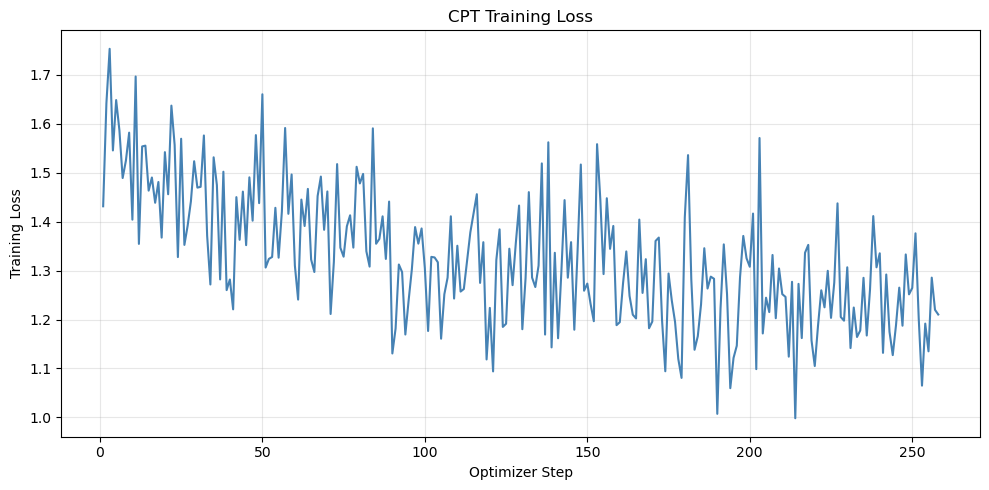

Initial loss: 1.4314
Final loss:   1.2103
Minimum loss: 0.9982


In [13]:
import json
import matplotlib.pyplot as plt

history_path = CPT_OUTPUT_DIR / "training_history.json"
history = json.loads(history_path.read_text(encoding="utf-8"))

steps = [entry["step"] for entry in history]
losses = [entry["loss"] for entry in history]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, color="steelblue", linewidth=1.5)
plt.xlabel("Optimizer Step")
plt.ylabel("Training Loss")
plt.title("CPT Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.4f}")
print(f"Minimum loss: {min(losses):.4f}")

### CPT Summary Metrics and Results

In [12]:
import json
from collections import defaultdict
from statistics import mean

training_run_path = CPT_OUTPUT_DIR / "training_run.json"
training_history_path = CPT_OUTPUT_DIR / "training_history.json"

training_run = json.loads(training_run_path.read_text(encoding="utf-8"))
history = json.loads(training_history_path.read_text(encoding="utf-8"))

model_info = training_run["model"]
dataset_info = training_run["dataset"]
hyperparameters = training_run["hyperparameters"]
training_plan = training_run["training_plan"]
results = training_run["results"]

initial_loss = history[0]["loss"]
final_loss = history[-1]["loss"]
minimum_loss = min(item["loss"] for item in history)

initial_ppl = history[0]["perplexity"]
final_ppl = history[-1]["perplexity"]
loss_reduction = (initial_loss - final_loss) / initial_loss * 100

print("=" * 72)
print("CPT TRAINING RUN SUMMARY")
print("=" * 72)

print(f"Status:                         {training_run['status']}")
print(f"Model:                          {model_info['name_or_path']}")
print(f"Model architecture:             {model_info['model_type']}")
print(f"Trainable parameters:           {model_info['trainable_parameters']:,}")
print(f"Device:                         {model_info['device']}")
print(f"Training precision:             {hyperparameters['precision']}")
print()

print(f"Packed training sequences:      {dataset_info['packed_sequence_count']:,}")
print(f"Context length:                 {dataset_info['context_length']:,}")
print(f"Epochs:                         {hyperparameters['epochs']}")
print(f"Micro-batch size:               {hyperparameters['micro_batch_size']}")
print(f"Gradient accumulation:          {hyperparameters['gradient_accumulation_steps']}")
print(f"Effective batch size:           {hyperparameters['effective_batch_size']}")
print(f"Optimizer:                      {hyperparameters['optimizer']}")
print(f"Learning-rate scheduler:        {hyperparameters['scheduler']}")
print(f"Peak learning rate:             {hyperparameters['learning_rate']:.2e}")
print(f"Warmup steps:                   {hyperparameters['warmup_steps']}")
print(f"Total optimizer steps:          {training_plan['total_optimizer_steps']}")
print()

print("-" * 72)
print("LOSS RESULTS")
print("-" * 72)
print(f"Initial logged loss:            {initial_loss:.4f}")
print(f"Final logged loss:              {final_loss:.4f}")
print(f"Minimum logged loss:            {minimum_loss:.4f}")
print(f"Overall loss reduction:         {loss_reduction:.2f}%")
print(f"Initial training perplexity:    {initial_ppl:.2f}")
print(f"Final training perplexity:      {final_ppl:.2f}")
print(f"Training duration:              {results['elapsed_seconds'] / 60:.2f} minutes")

# Summarize loss by epoch.
epoch_losses = defaultdict(list)
for record in history:
    epoch_losses[int(record["epoch"])].append(record["loss"])

print("\nLOSS BY EPOCH")
print(f"{'Epoch':>5} | {'Updates':>7} | {'Mean loss':>10} | "
      f"{'Min loss':>10} | {'Final loss':>10}")
print("-" * 55)

for epoch, losses in sorted(epoch_losses.items()):
    print(
        f"{epoch:5d} | {len(losses):7d} | {mean(losses):10.4f} | "
        f"{min(losses):10.4f} | {losses[-1]:10.4f}"
    )

# Compare the last two windows to identify whether loss has plateaued.
window = min(20, max(5, len(history) // 10))
plateau_message = "Insufficient history to assess the final plateau."

if len(history) >= 2 * window:
    previous_average = mean(
        item["loss"] for item in history[-2 * window:-window]
    )
    recent_average = mean(
        item["loss"] for item in history[-window:]
    )
    recent_change = (
        (recent_average - previous_average) / previous_average * 100
    )

    if abs(recent_change) < 2:
        plateau_message = (
            f"Loss has approximately plateaued: the final {window} steps "
            f"changed by only {recent_change:+.2f}%."
        )
    elif recent_change < 0:
        plateau_message = (
            f"Loss was still improving near completion: the final "
            f"{window} steps changed by {recent_change:+.2f}%."
        )
    else:
        plateau_message = (
            f"Recent loss increased by {recent_change:+.2f}%. "
            "Inspect the loss curve for noise or overtraining."
        )

print("\n" + "-" * 72)
print("INTERPRETATION")
print("-" * 72)

if training_run["status"] == "completed":
    print("✓ Training completed and the final model was saved.")
else:
    print("⚠ The run metadata does not indicate successful completion.")

if final_loss < initial_loss:
    print(
        f"✓ Loss decreased by {loss_reduction:.2f}%, indicating that the "
        "model learned the domain token distribution."
    )
else:
    print("⚠ Final loss did not improve over the initial logged loss.")

print(f"• {plateau_message}")
print(
    "• Training loss alone does not establish generalization. The held-out "
    "base-versus-CPT perplexity comparison in Step 5 is the decisive result."
)
print("=" * 72)

CPT TRAINING RUN SUMMARY
Status:                         completed
Model:                          Qwen/Qwen2.5-1.5B
Model architecture:             qwen2
Trainable parameters:           1,543,714,304
Device:                         cuda
Training precision:             torch.bfloat16

Packed training sequences:      1,373
Context length:                 2,048
Epochs:                         3
Micro-batch size:               1
Gradient accumulation:          16
Effective batch size:           16
Optimizer:                      AdamW
Learning-rate scheduler:        cosine_with_linear_warmup
Peak learning rate:             5.00e-06
Warmup steps:                   12
Total optimizer steps:          258

------------------------------------------------------------------------
LOSS RESULTS
------------------------------------------------------------------------
Initial logged loss:            1.4314
Final logged loss:              1.2050
Minimum logged loss:            0.9917
Overall loss re

<a id="step-5-perplexity-and-catastrophic-forgetting-evaluation"></a>
## Step 5 Perplexity and Catastrophic Forgetting Evaluation

### Domain perplexity

Domain perplexity measures how well the model predicts unseen Cisco data-center text. The evaluation follows these steps:

1. **Create a held-out domain split.** Before tokenization, the cleaned documents are divided into 90% training and 10% evaluation sets. Entire documents are assigned to only one split, preventing evaluation data from appearing during CPT.

2. **Tokenize and pack the evaluation documents.** The held-out documents are tokenized using the same Qwen tokenizer used for training. Their token IDs are concatenated and divided into fixed-length sequences of 2,048 tokens. These sequences are saved in `token_test.bin` and are never used for parameter updates.

3. **Evaluate the original base model.** The pretrained model processes every held-out sequence with gradients disabled. Using teacher forcing, the correct preceding tokens are supplied while the model predicts each next token. These predictions are compared with the actual next tokens using cross-entropy loss.

4. **Evaluate the CPT model.** The same evaluation is repeated using the saved CPT checkpoint. Both models receive exactly the same token sequences, labels and evaluation settings, making their results directly comparable.

5. **Accumulate token-weighted loss.** Negative log-likelihood is accumulated across all predicted tokens. Weighting by token count produces a corpus-level average and avoids giving smaller batches the same importance as larger batches.

6. **Calculate perplexity.** Average negative log-likelihood is converted into perplexity using:

   `PPL = exp(total negative log-likelihood / total predicted tokens)`

7. **Compare the two models.** The percentage reduction in perplexity is calculated using:

   `PPL reduction (%) = ((base PPL − CPT PPL) / base PPL) × 100`

A lower CPT perplexity means that the adapted model assigns a higher probability to the correct tokens in previously unseen domain text. This indicates that CPT improved the model’s understanding of domain terminology, sentence structure and technical patterns.

Perplexity evaluates how well a model predicts fixed reference text. It does not directly evaluate the quality or factual correctness of freely generated answers; generated responses and catastrophic forgetting are therefore evaluated separately.


### Catastrophic forgetting

Catastrophic forgetting occurs when continual pre-training on a specialized corpus causes a model to lose some of the general knowledge or language capability acquired during its original pretraining. The evaluation checks whether the CPT model retains the base model’s performance on prompts unrelated to Cisco data-center networking.

The forgetting evaluation follows these steps:

1. **Select general-domain prompts.** A fixed set of general-knowledge prompts is prepared using topics unrelated to the CPT corpus, such as geography, science and everyday factual knowledge. These prompts are not used during CPT training.

2. **Generate base-model responses.** Each prompt is passed to the original pretrained model. The generated responses establish the model’s general-purpose behaviour before domain adaptation.

3. **Generate CPT-model responses.** The same prompts are passed to the CPT model using identical generation parameters.

4. **Use deterministic generation.** Greedy decoding is used for both models by setting sampling to disabled and selecting the highest-probability token at each step. This prevents random sampling differences from being mistaken for forgetting.

5. **Compare responses side by side.** The base and CPT responses are displayed together so that factual correctness, relevance, coherence and repetition can be compared directly.

6. **Measure response retention.** The base response is also treated as a fixed reference continuation. Both models score that same response using conditional perplexity. A large increase in the CPT model’s score indicates that it has moved substantially away from the base model’s general-language behaviour.

7. **Assign a verdict.** Each prompt receives one of the following verdicts:

   - **Retained:** The CPT response preserves the relevant concepts and does not show a material increase in repetition or divergence from the base response.
   - **Degraded:** The CPT response loses relevant concepts, becomes empty or incoherent, shows substantially more repetition, or assigns considerably lower probability to the original base response.

8. **Summarize forgetting.** The number of retained and degraded responses is reported. A high retained-response rate indicates that CPT improved domain adaptation without significantly damaging general capability.

Unlike domain perplexity, this check is primarily a comparative generation evaluation. There is no single universally accepted numerical threshold that proves catastrophic forgetting. The side-by-side responses, retention perplexity and explicit verdicts together provide evidence of whether general capability was preserved.

If several general responses are degraded, likely causes include an excessive learning rate, too many training steps, or an overly narrow and repetitive training corpus. These effects can usually be reduced by lowering the learning rate, shortening CPT or mixing a small amount of general-domain text into the training data.


### Perplexity and Catastrophic Forgetting check Code

In [14]:
# Evaluate Perplexity before and after CPT
#
# Adapted from evaluate_cpt.py for one selected Qwen base/CPT pair.
# The public entry point accepts one query folder and one output folder.

import gc
import re
import textwrap
from collections import Counter, defaultdict


REFERENCE_FIELDS = (
    "expected_continuation",
    "expected_response",
    "reference_answer",
    "expected_answer",
)


def _sha256(path):
    """Identify the exact held-out file used in the comparison."""
    path = Path(path).expanduser().resolve()
    digest = hashlib.sha256()
    with path.open("rb") as input_file:
        for block in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def _load_metrics(path):
    """Load tokenization metadata used to validate an evaluation binary."""
    if path is None:
        return None, None
    path = Path(path).expanduser().resolve()
    if not path.is_file():
        raise FileNotFoundError(f"Dataset metrics were not found: {path}")
    try:
        return json.loads(path.read_text(encoding="utf-8")), str(path)
    except json.JSONDecodeError as error:
        raise ValueError(f"Invalid dataset metrics JSON: {path}") from error


def _set_label(query_filename):
    labels = {
        "domain_baseline_queries.json": "domain",
        "domain_exact_generation_queries.json": "exact",
        "domain_generalization_queries.json": "generalize",
        "generic_forgetting_queries.json": "general",
    }
    return labels.get(
        query_filename,
        Path(query_filename).stem.replace("_queries", ""),
    )


def load_evaluation_queries(query_folder):
    """Load every query JSON from one input folder."""
    query_folder = Path(query_folder).expanduser().resolve()
    if not query_folder.is_dir():
        raise FileNotFoundError(f"Query folder was not found: {query_folder}")

    query_paths = sorted(query_folder.glob("*.json"))
    if not query_paths:
        raise ValueError(f"Query folder contains no JSON files: {query_folder}")

    records = []
    seen_keys = set()
    for query_path in query_paths:
        data = json.loads(query_path.read_text(encoding="utf-8"))
        queries = data.get("queries")
        if not isinstance(queries, list):
            raise ValueError(f"'queries' must be a list in {query_path}")

        for index, query in enumerate(queries):
            query_id = query.get("id")
            prompt = query.get("prompt")
            if query_id is None:
                raise ValueError(f"Query {index} has no id in {query_path}")
            if not isinstance(prompt, str) or not prompt.strip():
                raise ValueError(f"Query {query_id} has no prompt in {query_path}")
            key = (query_path.name, str(query_id))
            if key in seen_keys:
                raise ValueError(f"Duplicate query: {key}")
            seen_keys.add(key)
            records.append(
                {
                    **query,
                    "prompt": prompt.strip(),
                    "query_file": query_path.name,
                    "query_set": _set_label(query_path.name),
                }
            )
        print(f"Loaded {len(queries):,} queries from: {query_path.name}")
    return records


def _words(text):
    return re.findall(r"[a-z0-9]+", str(text or "").casefold())


def _normalized(text):
    return " ".join(_words(text))


def _concept_matches(concept, response):
    """Match expected phrases, including explicit 'x or y' alternatives."""
    normalized_response = f" {_normalized(response)} "
    alternatives = re.split(r"\s+or\s+", str(concept), flags=re.IGNORECASE)
    for value in alternatives:
        alternative = _normalized(value)
        if not alternative:
            continue
        if f" {alternative} " in normalized_response:
            return True
        compact = alternative.replace(" ", "")
        if len(compact) <= 5 and compact in normalized_response.replace(" ", ""):
            return True
    return False


def _longest_common_prefix_ratio(response, expected):
    response_words = _words(response)
    expected_words = _words(expected)
    if not expected_words:
        return 0.0
    matched = 0
    for actual, reference in zip(response_words, expected_words):
        if actual != reference:
            break
        matched += 1
    return matched / len(expected_words)


def _expected_token_coverage(response, expected):
    expected_counts = Counter(_words(expected))
    if not expected_counts:
        return 0.0
    response_counts = Counter(_words(response))
    overlap = sum(
        min(count, response_counts[token])
        for token, count in expected_counts.items()
    )
    return overlap / sum(expected_counts.values())


def _repetition_ratio(response, ngram_size=3):
    words = _words(response)
    ngrams = [
        tuple(words[index:index + ngram_size])
        for index in range(len(words) - ngram_size + 1)
    ]
    return 0.0 if not ngrams else 1.0 - len(set(ngrams)) / len(ngrams)


def score_record(record):
    """Calculate deterministic lexical generation diagnostics."""
    response = str(record.get("response") or "")
    concepts = record.get("expected_concepts") or []
    concept_hits = [
        concept for concept in concepts if _concept_matches(concept, response)
    ]
    expected = str(record.get("expected_continuation") or "")
    exact_prefix = bool(expected) and _normalized(response).startswith(
        _normalized(expected)
    )
    return {
        "concept_hits": concept_hits,
        "concept_hit_count": len(concept_hits),
        "concept_count": len(concepts),
        "concept_recall": (
            len(concept_hits) / len(concepts) if concepts else None
        ),
        "exact_continuation_prefix": exact_prefix if expected else None,
        "continuation_longest_common_prefix_ratio": (
            _longest_common_prefix_ratio(response, expected) if expected else None
        ),
        "continuation_token_coverage": (
            _expected_token_coverage(response, expected) if expected else None
        ),
        "repeated_trigram_ratio": _repetition_ratio(response),
    }


@torch.inference_mode()
def generate_responses(
    model,
    tokenizer,
    prompts,
    max_new_tokens=100,
    batch_size=2,
):
    """Generate deterministic completion-style responses."""
    if not prompts:
        return []
    model.eval()
    device = next(model.parameters()).device
    if tokenizer.pad_token_id is None:
        if tokenizer.eos_token_id is None:
            raise ValueError("Batched generation requires a PAD or EOS token.")
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model_limit = model_context_limit(model.config, tokenizer)
    if model_limit is None:
        raise ValueError("Unable to determine the model context length.")
    max_prompt_length = model_limit - max_new_tokens
    if max_prompt_length <= 0:
        raise ValueError("max_new_tokens must be below the model context length.")

    responses = []
    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]
        encoded = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_prompt_length,
            return_attention_mask=True,
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        generated = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        prompt_width = encoded["input_ids"].shape[1]
        responses.extend(
            response.strip()
            for response in tokenizer.batch_decode(
                generated[:, prompt_width:],
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )
        )
    return responses


def _model_context_length(model, tokenizer):
    context_length = model_context_limit(model.config, tokenizer)
    if context_length is None:
        raise ValueError("Unable to determine the model context length.")
    return context_length


def _validate_packed_dataset(
    bin_file,
    context_length,
    model,
    tokenizer,
    metrics,
):
    """Validate that a held-out stream is safe to score."""
    bin_file = Path(bin_file).expanduser().resolve()
    if not bin_file.is_file():
        raise FileNotFoundError(f"Held-out token file was not found: {bin_file}")
    binary_dtype = normalize_binary_dtype(
        metrics.get("binary_dtype") if metrics is not None else "uint16"
    )
    if bin_file.stat().st_size % binary_dtype.itemsize:
        raise ValueError(f"Invalid {binary_dtype.name} file size: {bin_file}")

    stored_tokens = bin_file.stat().st_size // binary_dtype.itemsize
    if stored_tokens < context_length or stored_tokens % context_length:
        raise ValueError(
            f"{stored_tokens:,} held-out tokens do not form complete "
            f"{context_length:,}-token sequences."
        )
    if context_length > _model_context_length(model, tokenizer):
        raise ValueError("Evaluation context exceeds the model context limit.")

    dataset = PackedTokenDataset(
        bin_file,
        sequence_length=context_length,
        binary_dtype=binary_dtype,
    )
    maximum_token_id = int(dataset.data.max())
    if maximum_token_id >= int(model.config.vocab_size):
        raise ValueError("Held-out token IDs exceed the model vocabulary.")

    if metrics is not None:
        metrics_context = metrics.get("packing_context_length")
        if metrics_context is not None and int(metrics_context) != context_length:
            raise ValueError("Dataset metrics and context length disagree.")
        metrics_vocab = metrics.get("tokenizer_vocabulary_size")
        if metrics_vocab is not None and int(metrics_vocab) != len(tokenizer):
            raise ValueError("Dataset and model tokenizer sizes disagree.")
        metrics_fingerprint = metrics.get("tokenizer_vocabulary_sha256")
        if (
            metrics_fingerprint is not None
            and metrics_fingerprint != tokenizer_vocabulary_sha256(tokenizer)
        ):
            raise ValueError("Dataset and model token-to-ID mappings disagree.")

    provenance = {
        "bin_file": str(bin_file),
        "sha256": _sha256(bin_file),
        "binary_dtype": binary_dtype.name,
        "file_size_bytes": bin_file.stat().st_size,
        "stored_token_count": stored_tokens,
        "context_length": context_length,
        "packed_sequence_count": len(dataset),
        "maximum_token_id": maximum_token_id,
    }
    return dataset, provenance


def evaluate_held_out_perplexity(
    model,
    tokenizer,
    device,
    bin_file,
    *,
    context_length,
    batch_size,
    num_workers,
    metrics,
):
    """Calculate token-weighted perplexity on fixed held-out text.

    The model receives labels=input_ids, and Hugging Face performs the
    causal one-token shift internally. Batch mean loss is multiplied by
    the number of predicted tokens to recover total negative
    log-likelihood. PPL = exp(total NLL / total predicted tokens).
    """
    dataset, provenance = _validate_packed_dataset(
        bin_file, context_length, model, tokenizer, metrics
    )
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.device(device).type == "cuda",
        drop_last=False,
    )
    original_use_cache = getattr(model.config, "use_cache", None)
    if original_use_cache is not None:
        model.config.use_cache = False

    model.eval()
    total_nll = 0.0
    total_predicted_tokens = 0
    started = time.time()
    try:
        with torch.inference_mode():
            for batch_index, batch in enumerate(dataloader, start=1):
                input_ids = batch["input_ids"].to(device, non_blocking=True)
                outputs = model(input_ids=input_ids, labels=input_ids)
                predicted_tokens = input_ids.shape[0] * (input_ids.shape[1] - 1)
                total_nll += (
                    outputs.loss.detach().float().item() * predicted_tokens
                )
                total_predicted_tokens += predicted_tokens
                if batch_index % 50 == 0 or batch_index == len(dataloader):
                    print(
                        f"  evaluated {batch_index:,}/{len(dataloader):,} "
                        "held-out batches"
                    )
    finally:
        if original_use_cache is not None:
            model.config.use_cache = original_use_cache

    if total_predicted_tokens == 0:
        raise ValueError("Held-out evaluation produced no predicted tokens.")
    mean_nll = total_nll / total_predicted_tokens
    return {
        **provenance,
        "batch_size": batch_size,
        "num_workers": num_workers,
        "evaluated_token_count": total_predicted_tokens,
        "total_negative_log_likelihood": total_nll,
        "mean_cross_entropy_loss": mean_nll,
        "perplexity": cpt_perplexity(mean_nll),
        "elapsed_seconds": time.time() - started,
        "method": "exp(total_negative_log_likelihood / evaluated_token_count)",
    }


def _join_prompt_and_target(prompt, target):
    separator = "" if prompt[-1:].isspace() or target[:1].isspace() else " "
    return prompt + separator + target, len(prompt)


def evaluate_conditional_perplexity(model, tokenizer, device, prompt, target):
    """Score fixed target tokens conditioned on a prompt.

    Prompt labels are masked with -100, so the prompt supplies context but
    only the authoritative target contributes to loss. Base and CPT must
    score the identical target for a valid comparison.
    """
    prompt = str(prompt).strip()
    target = str(target).strip()
    if not prompt or not target:
        raise ValueError("Conditional PPL requires a prompt and target.")

    combined, target_start = _join_prompt_and_target(prompt, target)
    try:
        encoded = tokenizer(
            combined, add_special_tokens=False, return_offsets_mapping=True
        )
    except (NotImplementedError, TypeError, ValueError):
        encoded = tokenizer(combined, add_special_tokens=False)
    input_ids = list(encoded["input_ids"])
    offsets = encoded.get("offset_mapping")
    if offsets is not None:
        labels = [
            token_id if end > target_start else -100
            for token_id, (_, end) in zip(input_ids, offsets)
        ]
    else:
        prompt_tokens = len(
            tokenizer(
                combined[:target_start], add_special_tokens=False
            )["input_ids"]
        )
        labels = [-100] * prompt_tokens + input_ids[prompt_tokens:]

    model_limit = _model_context_length(model, tokenizer)
    original_token_count = len(input_ids)
    if len(input_ids) > model_limit:
        input_ids = input_ids[-model_limit:]
        labels = labels[-model_limit:]

    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    label_tensor = torch.tensor([labels], dtype=torch.long, device=device)
    predicted_target_tokens = int((label_tensor[:, 1:] != -100).sum().item())
    if predicted_target_tokens == 0:
        raise ValueError("No target tokens remain for conditional scoring.")

    model.eval()
    with torch.inference_mode():
        loss = model(input_ids=input_tensor, labels=label_tensor).loss
    mean_nll = loss.detach().float().item()
    return {
        "target_token_count": predicted_target_tokens,
        "negative_log_likelihood": mean_nll * predicted_target_tokens,
        "mean_cross_entropy_loss": mean_nll,
        "perplexity": cpt_perplexity(mean_nll),
        "combined_token_count": len(input_ids),
        "left_truncated_tokens": max(0, original_token_count - len(input_ids)),
    }


def _reference_for_query(record):
    for field in REFERENCE_FIELDS:
        value = record.get(field)
        if isinstance(value, str) and value.strip():
            return field, value.strip()
    return None, None


def _aggregate_conditional(records, field):
    scores = [record[field] for record in records if record.get(field)]
    token_count = sum(score["target_token_count"] for score in scores)
    if token_count == 0:
        return None
    total_nll = sum(score["negative_log_likelihood"] for score in scores)
    mean_nll = total_nll / token_count
    return {
        "query_count": len(scores),
        "target_token_count": token_count,
        "total_negative_log_likelihood": total_nll,
        "mean_cross_entropy_loss": mean_nll,
        "perplexity": cpt_perplexity(mean_nll),
    }


def _summarize_query_results(results):
    groups = defaultdict(list)
    for record in results:
        groups[record["query_set"]].append(record)

    summaries = {}
    for name, records in sorted(groups.items()):
        concept_hits = sum(
            record["generation_metrics"]["concept_hit_count"]
            for record in records
        )
        concept_count = sum(
            record["generation_metrics"]["concept_count"]
            for record in records
        )
        exact_records = [
            record for record in records
            if record["generation_metrics"]["exact_continuation_prefix"]
            is not None
        ]
        summaries[name] = {
            "query_count": len(records),
            "generation": {
                "concept_hits": concept_hits,
                "concept_count": concept_count,
                "concept_recall": (
                    concept_hits / concept_count if concept_count else None
                ),
                "exact_continuation_matches": sum(
                    bool(record["generation_metrics"]["exact_continuation_prefix"])
                    for record in exact_records
                ),
                "exact_continuation_query_count": len(exact_records),
                "average_continuation_lcp": (
                    sum(
                        record["generation_metrics"][
                            "continuation_longest_common_prefix_ratio"
                        ]
                        for record in exact_records
                    ) / len(exact_records) if exact_records else None
                ),
                "average_continuation_token_coverage": (
                    sum(
                        record["generation_metrics"]["continuation_token_coverage"]
                        for record in exact_records
                    ) / len(exact_records) if exact_records else None
                ),
                "average_repeated_trigram_ratio": sum(
                    record["generation_metrics"]["repeated_trigram_ratio"]
                    for record in records
                ) / len(records),
            },
            "fixed_reference_conditional_ppl": _aggregate_conditional(
                records, "fixed_reference_conditional_ppl"
            ),
            "baseline_response_retention_ppl": _aggregate_conditional(
                records, "baseline_response_retention_ppl"
            ),
        }
    return summaries


def evaluate_queries(
    model,
    tokenizer,
    device,
    queries,
    baseline_targets,
    *,
    max_new_tokens,
    generation_batch_size,
):
    """Generate responses and score reference and retention targets."""
    prompts = [record["prompt"] for record in queries]
    responses = generate_responses(
        model, tokenizer, prompts, max_new_tokens, generation_batch_size
    )
    results = []
    for record, response in zip(queries, responses):
        result = {
            **record,
            "generated_response": response,
            "generation_metrics": score_record(
                {**record, "response": response}
            ),
            "fixed_reference_conditional_ppl": None,
            "baseline_response_retention_ppl": None,
        }
        reference_field, reference = _reference_for_query(record)
        if reference is not None:
            result["fixed_reference_field"] = reference_field
            result["fixed_reference"] = reference
            result["fixed_reference_conditional_ppl"] = (
                evaluate_conditional_perplexity(
                    model, tokenizer, device, record["prompt"], reference
                )
            )
        baseline_target = baseline_targets.get(
            (record["query_file"], str(record["id"]))
        )
        if baseline_target is not None:
            result["baseline_response_target"] = baseline_target
            result["baseline_response_retention_ppl"] = (
                evaluate_conditional_perplexity(
                    model, tokenizer, device, record["prompt"], baseline_target
                )
            )
        results.append(result)
    return {
        "generation_configuration": {
            "decoding": "greedy",
            "do_sample": False,
            "num_beams": 1,
            "max_new_tokens": max_new_tokens,
            "batch_size": generation_batch_size,
        },
        "summary_by_query_set": _summarize_query_results(results),
        "results": results,
    }


def add_base_response_retention_scores(
    model, tokenizer, device, query_evaluation
):
    """Use newly generated base responses as fixed targets for both models."""
    targets = {}
    for result in query_evaluation["results"]:
        key = (result["query_file"], str(result["id"]))
        target = result["generated_response"].strip()
        if not target:
            continue
        targets[key] = target
        result["baseline_response_target"] = target
        result["baseline_response_retention_ppl"] = (
            evaluate_conditional_perplexity(
                model, tokenizer, device, result["prompt"], target
            )
        )
    query_evaluation["summary_by_query_set"] = _summarize_query_results(
        query_evaluation["results"]
    )
    return targets


def _relative_change(before, after):
    absolute = after - before
    return {
        "base": before,
        "cpt": after,
        "absolute_change": absolute,
        "relative_change_percent": absolute / before * 100 if before else None,
    }


def _assessment(verdict, remarks):
    return {"verdict": verdict, "remarks": remarks}


def _assess_held_out_ppl(dataset_name, values):
    change = values["relative_change_percent"]
    if dataset_name == "domain":
        reduction = -change
        if reduction >= 10:
            return _assessment(
                "Good", f"Domain PPL decreased {reduction:.2f}%."
            )
        if reduction > 0:
            return _assessment(
                "Satisfactory", f"Domain PPL decreased {reduction:.2f}%."
            )
        return _assessment(
            "Needs Improvement", f"Domain PPL increased {-reduction:.2f}%."
        )
    if change <= 5:
        return _assessment("Good", f"Generic PPL changed {change:+.2f}%.")
    if change <= 10:
        return _assessment(
            "Satisfactory", f"Generic PPL increased {change:.2f}%."
        )
    return _assessment(
        "Needs Improvement", f"Generic PPL increased {change:.2f}%."
    )


def _assess_concept_recall(base, cpt):
    if base is None or cpt is None:
        return _assessment("Needs Improvement", "Concept recall unavailable.")
    change_pp = 100 * (cpt - base)
    verdict = (
        "Good" if cpt >= 0.60 and change_pp >= -2
        else "Satisfactory" if cpt >= 0.30 and change_pp >= -5
        else "Needs Improvement"
    )
    return _assessment(
        verdict, f"CPT recall {100 * cpt:.1f}%; change {change_pp:+.1f} pp."
    )


def _assess_repetition(base, cpt):
    change_pp = 100 * (cpt - base)
    verdict = "Good" if cpt <= 0.10 else "Satisfactory" if cpt <= 0.30 else "Needs Improvement"
    return _assessment(
        verdict, f"CPT repetition {100 * cpt:.1f}%; change {change_pp:+.1f} pp."
    )


def _assess_fixed_reference(values):
    reduction = -values["relative_change_percent"]
    verdict = "Good" if reduction >= 10 else "Satisfactory" if reduction > 0 else "Needs Improvement"
    return _assessment(
        verdict,
        f"Fixed-reference PPL changed {values['relative_change_percent']:+.2f}%.",
    )


def _assess_retention(values):
    change = values["relative_change_percent"]
    verdict = "Good" if change <= 5 else "Satisfactory" if change <= 10 else "Needs Improvement"
    return _assessment(
        verdict, f"Baseline-response PPL changed {change:+.2f}%."
    )


def _validate_comparable_models(base_details, cpt_details):
    if base_details["model_type"] != cpt_details["model_type"]:
        raise ValueError("Base and CPT architectures differ.")
    if (
        base_details["tokenizer_vocabulary_sha256"]
        != cpt_details["tokenizer_vocabulary_sha256"]
    ):
        raise ValueError("Base and CPT token-to-ID mappings differ.")


def _build_comparison(report):
    base = report["models"]["base"]
    cpt = report["models"]["cpt"]
    comparison = {"held_out": {}, "queries": {}}
    for dataset_name in ("domain", "generic"):
        base_ppl = base["held_out_perplexity"].get(dataset_name)
        cpt_ppl = cpt["held_out_perplexity"].get(dataset_name)
        if base_ppl and cpt_ppl:
            values = _relative_change(
                base_ppl["perplexity"], cpt_ppl["perplexity"]
            )
            values.update(_assess_held_out_ppl(dataset_name, values))
            comparison["held_out"][dataset_name] = values

    base_sets = base["query_evaluation"]["summary_by_query_set"]
    cpt_sets = cpt["query_evaluation"]["summary_by_query_set"]
    for name in sorted(set(base_sets) & set(cpt_sets)):
        base_summary = base_sets[name]
        cpt_summary = cpt_sets[name]
        item = {
            "generation_concept_recall": {
                "base": base_summary["generation"]["concept_recall"],
                "cpt": cpt_summary["generation"]["concept_recall"],
            },
            "generation_repeated_trigram_ratio": {
                "base": base_summary["generation"]["average_repeated_trigram_ratio"],
                "cpt": cpt_summary["generation"]["average_repeated_trigram_ratio"],
            },
        }
        item["generation_concept_recall"].update(
            _assess_concept_recall(
                item["generation_concept_recall"]["base"],
                item["generation_concept_recall"]["cpt"],
            )
        )
        item["generation_repeated_trigram_ratio"].update(
            _assess_repetition(
                item["generation_repeated_trigram_ratio"]["base"],
                item["generation_repeated_trigram_ratio"]["cpt"],
            )
        )
        for field in (
            "fixed_reference_conditional_ppl",
            "baseline_response_retention_ppl",
        ):
            base_score = base_summary.get(field)
            cpt_score = cpt_summary.get(field)
            if base_score and cpt_score:
                item[field] = _relative_change(
                    base_score["perplexity"], cpt_score["perplexity"]
                )
                assessment = (
                    _assess_fixed_reference(item[field])
                    if field == "fixed_reference_conditional_ppl"
                    else _assess_retention(item[field])
                )
                item[field].update(assessment)
        comparison["queries"][name] = item
    return comparison


def _generated_pair_verdict(base_result, cpt_result):
    """Mark material loss of concepts or increased repetition as degraded."""
    base_metrics = base_result["generation_metrics"]
    cpt_metrics = cpt_result["generation_metrics"]
    lost_concept = (
        cpt_metrics["concept_hit_count"] < base_metrics["concept_hit_count"]
    )
    repetition_increase = (
        cpt_metrics["repeated_trigram_ratio"]
        - base_metrics["repeated_trigram_ratio"] > 0.10
    )
    base_retention = base_result.get("baseline_response_retention_ppl")
    cpt_retention = cpt_result.get("baseline_response_retention_ppl")
    retention_increase = False
    if base_retention and cpt_retention and base_retention["perplexity"]:
        retention_increase = (
            (cpt_retention["perplexity"] - base_retention["perplexity"])
            / base_retention["perplexity"] * 100 > 10
        )
    degraded = (
        not cpt_result["generated_response"].strip()
        or lost_concept
        or repetition_increase
        or retention_increase
    )
    return "Degraded" if degraded else "Retained"


def _forgetting_rows(report, limit=10):
    base_results = report["models"]["base"]["query_evaluation"]["results"]
    cpt_results = report["models"]["cpt"]["query_evaluation"]["results"]
    cpt_by_key = {
        (record["query_file"], str(record["id"])): record
        for record in cpt_results
    }
    rows = []
    for base_result in base_results:
        if base_result["query_set"] != "general":
            continue
        key = (base_result["query_file"], str(base_result["id"]))
        cpt_result = cpt_by_key[key]
        rows.append(
            {
                "id": base_result["id"],
                "query": base_result["prompt"],
                "base": base_result["generated_response"],
                "cpt": cpt_result["generated_response"],
                "verdict": _generated_pair_verdict(
                    base_result, cpt_result
                ),
            }
        )
        if len(rows) == limit:
            break
    return rows


def _print_wrapped_table(headers, rows, widths):
    separator = "+" + "+".join("-" * (width + 2) for width in widths) + "+"

    def wrap(value, width):
        compact = " ".join(str(value or "").split())
        return textwrap.wrap(
            compact, width=width, break_long_words=True, break_on_hyphens=False
        ) or [""]

    def print_row(values):
        wrapped = [wrap(value, widths[index]) for index, value in enumerate(values)]
        for line in range(max(len(cell) for cell in wrapped)):
            cells = [
                (cell[line] if line < len(cell) else "").ljust(widths[index])
                for index, cell in enumerate(wrapped)
            ]
            print("| " + " | ".join(cells) + " |")

    print(separator)
    print_row(headers)
    print(separator)
    for row in rows:
        print_row(row)
        print(separator)


def _save_response_files(model_result, output_folder, label, timestamp):
    """Write one run-query-style response JSON per input query file."""
    grouped = defaultdict(list)
    for result in model_result["query_evaluation"]["results"]:
        response_record = {
            key: value for key, value in result.items()
            if key not in {"query_file", "query_set", "generated_response"}
        }
        response_record["response"] = result["generated_response"]
        grouped[result["query_file"]].append(response_record)

    saved = []
    for query_file, results in sorted(grouped.items()):
        path = output_folder / f"{label}_{Path(query_file).stem}_responses.json"
        payload = {
            "evaluation_stage": "pre_cpt" if label == "base" else "post_cpt",
            "timestamp_utc": timestamp,
            "model_name": model_result["model_details"]["name_or_path"],
            "model_details": model_result["model_details"],
            "query_source": query_file,
            "generation_configuration": model_result["query_evaluation"][
                "generation_configuration"
            ],
            "total_prompts": len(results),
            "results": results,
        }
        path.write_text(
            json.dumps(payload, indent=2, ensure_ascii=False) + "\n",
            encoding="utf-8",
        )
        saved.append(str(path))
    return saved


def _release_model(model_bundle):
    model_bundle.clear()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def evaluate_selected_cpt(
    model_name,
    cpt_model_folder,
    domain_test_bin,
    domain_metrics_file,
    query_folder,
    output_folder,
    *,
    generic_test_bin=None,
    generic_metrics_file=None,
    context_length=2048,
    batch_size=2,
    num_workers=0,
    max_new_tokens=100,
    generation_batch_size=2,
    forgetting_rows=10,
):
    """Run the four Part A evaluations for one base/CPT model pair."""
    output_folder = Path(output_folder).expanduser().resolve()
    output_folder.mkdir(parents=True, exist_ok=True)
    domain_test_bin = Path(domain_test_bin).expanduser().resolve()
    cpt_model_folder = Path(cpt_model_folder).expanduser().resolve()
    domain_metrics, domain_metrics_path = _load_metrics(domain_metrics_file)
    generic_metrics, generic_metrics_path = _load_metrics(generic_metrics_file)
    if generic_metrics_file is not None and generic_test_bin is None:
        raise ValueError("generic_metrics_file requires generic_test_bin.")
    if generic_test_bin is not None:
        generic_test_bin = Path(generic_test_bin).expanduser().resolve()
    queries = load_evaluation_queries(query_folder)

    def evaluate_checkpoint(label, model_folder, baseline_targets):
        print(f"\n=== Evaluating {label.upper()} model ===")
        bundle = load_causal_lm(
            model_name=model_name,
            model_folder=model_folder,
            for_training=False,
        )
        evaluated_model = bundle["model"]
        evaluated_tokenizer = bundle["tokenizer"]
        evaluated_device = bundle["device"]
        held_out = {
            "domain": evaluate_held_out_perplexity(
                evaluated_model, evaluated_tokenizer, evaluated_device,
                domain_test_bin, context_length=context_length,
                batch_size=batch_size, num_workers=num_workers,
                metrics=domain_metrics,
            )
        }
        if generic_test_bin is not None:
            held_out["generic"] = evaluate_held_out_perplexity(
                evaluated_model, evaluated_tokenizer, evaluated_device,
                generic_test_bin, context_length=context_length,
                batch_size=batch_size, num_workers=num_workers,
                metrics=generic_metrics,
            )
        query_evaluation = evaluate_queries(
            evaluated_model, evaluated_tokenizer, evaluated_device, queries,
            baseline_targets, max_new_tokens=max_new_tokens,
            generation_batch_size=generation_batch_size,
        )
        new_targets = baseline_targets
        if label == "base":
            new_targets = add_base_response_retention_scores(
                evaluated_model, evaluated_tokenizer, evaluated_device,
                query_evaluation,
            )
        result = {
            "label": label,
            "requested_model_name": model_name,
            "model_folder": str(model_folder) if model_folder else None,
            "model_details": causal_lm_model_details(
                evaluated_model, evaluated_tokenizer, evaluated_device
            ),
            "held_out_perplexity": held_out,
            "query_evaluation": query_evaluation,
        }
        del evaluated_model, evaluated_tokenizer
        _release_model(bundle)
        return result, new_targets

    base_result, baseline_targets = evaluate_checkpoint("base", None, {})
    cpt_result, _ = evaluate_checkpoint(
        "cpt", cpt_model_folder, baseline_targets
    )
    _validate_comparable_models(
        base_result["model_details"], cpt_result["model_details"]
    )

    timestamp = datetime.now(timezone.utc).isoformat()
    report = {
        "schema_version": 2,
        "created_at_utc": timestamp,
        "methodology": {
            "held_out_perplexity": "Token-weighted PPL on fixed packed text.",
            "fixed_reference_perplexity": "Conditional PPL on authoritative fixed targets.",
            "baseline_response_retention": "Both models score the same generated base response target.",
            "generation": "Greedy generation with concept, continuation, and repetition diagnostics.",
        },
        "inputs": {
            "domain_test_bin": str(domain_test_bin),
            "domain_metrics_file": domain_metrics_path,
            "generic_test_bin": str(generic_test_bin) if generic_test_bin else None,
            "generic_metrics_file": generic_metrics_path,
            "query_folder": str(Path(query_folder).expanduser().resolve()),
            "output_folder": str(output_folder),
        },
        "models": {"base": base_result, "cpt": cpt_result},
    }
    report["comparison"] = _build_comparison(report)
    report["catastrophic_forgetting"] = _forgetting_rows(
        report, limit=forgetting_rows
    )
    report["response_files"] = {
        "base": _save_response_files(
            base_result, output_folder, "base", timestamp
        ),
        "cpt": _save_response_files(
            cpt_result, output_folder, "cpt", timestamp
        ),
    }

    report_path = output_folder / "cpt_evaluation.json"
    report_path.write_text(
        json.dumps(report, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )

    print("\n=== Perplexity Evaluation ===")
    ppl_rows = []
    for dataset_name, values in report["comparison"]["held_out"].items():
        ppl_rows.append(
            [
                dataset_name,
                f"{values['base']:.4f}",
                f"{values['cpt']:.4f}",
                f"{values['relative_change_percent']:+.2f}%",
                values["verdict"],
                values["remarks"],
            ]
        )
    _print_wrapped_table(
        ["Dataset", "Base PPL", "CPT PPL", "Change", "Verdict", "Remarks"],
        ppl_rows, [10, 10, 10, 10, 18, 42],
    )

    print("\n=== Catastrophic Forgetting: Generic Queries ===")
    _print_wrapped_table(
        ["Query", "Base", "CPT", "Verdict"],
        [
            [row["query"], row["base"], row["cpt"], row["verdict"]]
            for row in report["catastrophic_forgetting"]
        ],
        [30, 40, 40, 9],
    )
    print(f"\nEvaluation report saved to: {report_path}")
    return report


### Evaluation and Results

In [15]:
# Run the available evaluations for the selected Qwen base/CPT pair.
# No separate generic held-out token binary is included in this submission,
# so generic PPL is omitted; generic-query generation still tests forgetting.
QUERY_FOLDER = PROJECT_ROOT / "evaluation" / "queries"
EVALUATION_OUTPUT_FOLDER = (
    PROJECT_ROOT / "evaluation" / "Qwen2.5-1.5B" / "v1"
)

evaluation_report = evaluate_selected_cpt(
    model_name=QWEN_MODEL_NAME,
    cpt_model_folder=cpt_artifacts["final_model_dir"],
    domain_test_bin=TOKENS_STORE / "token_test.bin",
    domain_metrics_file=TOKENS_STORE / "dataset_metrics_test.json",
    query_folder=QUERY_FOLDER,
    output_folder=EVALUATION_OUTPUT_FOLDER,
    generic_test_bin=None,
    generic_metrics_file=None,
    context_length=2048,
    batch_size=2,
    num_workers=0,
    max_new_tokens=100,
    generation_batch_size=2,
    forgetting_rows=10,
)


Loaded 20 queries from: domain_baseline_queries.json
Loaded 10 queries from: domain_exact_generation_queries.json
Loaded 10 queries from: domain_generalization_queries.json
Loaded 15 queries from: generic_forgetting_queries.json

=== Evaluating BASE model ===
Using device: cuda
Loading causal LM from: Qwen/Qwen2.5-1.5B
Successfully loaded Qwen/Qwen2.5-1.5B with 1,543,714,304 parameters using torch.float32 parameters.
  evaluated 50/239 held-out batches
  evaluated 100/239 held-out batches
  evaluated 150/239 held-out batches
  evaluated 200/239 held-out batches
  evaluated 239/239 held-out batches

=== Evaluating CPT model ===
Using device: cuda
Loading causal LM from: /home/jovyan/llmassign/1a/output/Qwen2.5-1.5B/v1/final_model


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Successfully loaded /home/jovyan/llmassign/1a/output/Qwen2.5-1.5B/v1/final_model with 1,543,714,304 parameters using torch.float32 parameters.
  evaluated 50/239 held-out batches
  evaluated 100/239 held-out batches
  evaluated 150/239 held-out batches
  evaluated 200/239 held-out batches
  evaluated 239/239 held-out batches

=== Perplexity Evaluation ===
+------------+------------+------------+------------+--------------------+--------------------------------------------+
| Dataset    | Base PPL   | CPT PPL    | Change     | Verdict            | Remarks                                    |
+------------+------------+------------+------------+--------------------+--------------------------------------------+
| domain     | 3.9927     | 3.5892     | -10.11%    | Good               | Domain PPL decreased 10.11%.               |
+------------+------------+------------+------------+--------------------+--------------------------------------------+

=== Catastrophic Forgetting: Generic Quer

### Evaluation Conclusions

The base and CPT models are also run on the same general-knowledge prompts that are unrelated to Cisco networking. Greedy decoding is used to remove sampling variation. Their answers are shown side by side with a `Retained` or `Degraded` verdict, allowing any loss of general-language capability after CPT to be identified.

The evaluation report additionally records model and CPT provenance, token counts, losses and generated-response diagnostics. Separate JSON artifacts are written for perplexity and generated text, making the reported tables reproducible without rerunning the models.

### Final evaluation verdict

| Evaluation | Observed result | Verdict |
|---|---:|---|
| Domain perplexity | Base PPL 3.9927 → CPT PPL 3.5896, a 10.10% reduction | **Good — successful domain adaptation** |
| Catastrophic forgetting | 8 of 10 displayed general responses retained; 2 degraded | **Mostly Retained — no widespread catastrophic forgetting** |

The lower held-out domain perplexity confirms that CPT improved prediction of unseen Cisco and networking text. General capability was largely preserved, although the two degraded responses and occasional verbosity or repetition show that some localized quality loss remains. Overall, the run achieved useful domain adaptation without a broad collapse in general-language behaviour.

<a id="generated-artifacts"></a>
## Generated Artifacts

| Artifact | Purpose |
|---|---|
| Cleaned `.txt` corpus | Training-ready domain documents |
| Cleaning audit JSON | Counts, rejection reasons and retained-original lineage |
| `token_train.bin` and `token_test.bin` | Efficient packed-token inputs for CPT and held-out evaluation |
| Train/test Parquet files | Portable fixed-length packed sequences |
| Dataset metrics JSON | Tokenizer, split, token-count and packing provenance |
| Baseline response JSON | Pre-CPT domain and general-query generations |
| `training_run.json` and `training_history.json` | Hyperparameters, reproducibility details and loss history |
| CPT `final_model` | Persisted adapted model and tokenizer |
| CPT evaluation JSON files | Held-out perplexity, generated responses and forgetting verdicts |